In [ ]:
%pip install datasets

### Роль RDKit в работе

**RDKit** используется как инструмент для работы с химической структурой молекул. В нашем проекте он выполняет три основные задачи:

1. **Проверка SMILES** — определяет, соответствует ли строка корректной химической структуре.
2. **Работа со структурой молекулы** — позволяет преобразовать SMILES в объект молекулы и анализировать его.
3. **Проверка результатов VAE** — после генерации новых SMILES с помощью VAE RDKit позволит определить, какие из них являются валидными молекулами.

Таким образом, **VAE отвечает за генерацию новых молекулярных структур, а RDKit — за их химическую обработку и проверку**.


In [ ]:
%pip install rdkit

In [ ]:
from datasets import load_dataset

ds = load_dataset("edmanft/zinc250k")

In [ ]:
print(ds)

In [ ]:
print(ds["train"].column_names)

### Описание данных датасета ZINC250K

Датасет содержит около 250 тысяч молекул. Для каждой молекулы представлены структурные представления и несколько рассчитанных молекулярных свойств.

* **`index`** — порядковый индекс записи в датасете. Не является химическим свойством молекулы и не используется в качестве входного признака для VAE.

* **`smiles`** — структурное представление молекулы в формате **SMILES (Simplified Molecular Input Line Entry System)**. Молекула записывается в виде строки символов, например `CCO`. В рамках данной работы `SMILES` является основным представлением молекул, которое будет использоваться для обучения генеративной модели.

* **`selfies`** — представление молекулы в формате **SELFIES (Self-Referencing Embedded Strings)**. Это альтернативный способ кодирования молекулярной структуры, разработанный с учётом получения синтаксически корректных молекулярных строк при генерации. В данной работе этот столбец может использоваться для сравнения с представлением SMILES.

* **`logP`** — коэффициент распределения вещества между органической и водной фазами в логарифмической шкале. Используется как характеристика **липофильности (гидрофобности)** молекулы. Чем выше значение `logP`, тем в среднем более липофильной является молекула.

* **`qed`** — количественная оценка **drug-likeness**, то есть соответствия молекулы некоторым свойствам, характерным для лекарственных соединений. Значение рассчитывается по совокупности молекулярных характеристик. Обычно находится в диапазоне от 0 до 1, где большее значение соответствует более высокому показателю drug-likeness.

* **`SAS`** — **Synthetic Accessibility Score**, оценка сложности синтеза молекулы. Показатель характеризует, насколько молекулу сложно получить химическим синтезом с учётом особенностей её структуры. Меньшее значение обычно соответствует более простой синтетической доступности, а большее — более сложной.

В данной работе столбец **`smiles`** будет использоваться как основное входное представление молекул для обучения VAE. Столбцы `logP`, `qed` и `SAS` будут использоваться для анализа свойств исходных и сгенерированных молекул. Столбцы `index` и, на первом этапе, `selfies` непосредственно в качестве входа стандартного VAE использоваться не будут.


Липофильность (гидрофобность) — это способность вещества лучше растворяться в жирах и органических растворителях, чем в воде.

Проще:

высокая липофильность → молекула плохо взаимодействует с водой, лучше — с жирами;
низкая липофильность → молекула лучше взаимодействует с водой.

Для logP: чем выше logP, тем более липофильной обычно является молекула.

In [ ]:
import pandas as pd

df = ds["train"].to_pandas()

print("Размер:", df.shape)
display(df.head())

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
print("Количество строк:", len(df))
print("\nПропуски:")
print(df.isnull().sum())

print("\nДубликаты SMILES:", df["smiles"].duplicated().sum())
print("Уникальных SMILES:", df["smiles"].nunique())

In [ ]:
Посмотрим табличные QED и SAS и сравним с расчетными

In [ ]:
from rdkit import Chem
from rdkit.Chem import QED
import pandas as pd

df = pd.read_csv("zinc250k.csv")

def calculate_qed(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return QED.qed(mol)

df["qed_calculated"] = df["smiles"].apply(calculate_qed)

df["qed_difference"] = (
    df["qed"] - df["qed_calculated"]
).abs()

print(df[["qed", "qed_calculated", "qed_difference"]].head())

print("Средняя ошибка:",
      df["qed_difference"].mean())

print("Максимальная ошибка:",
      df["qed_difference"].max())

print("Корреляция:",
      df[["qed", "qed_calculated"]].corr().iloc[0, 1])


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df["qed"],
    df["qed_calculated"],
    s=3,
    alpha=0.3
)

plt.xlabel("QED в датасете")
plt.ylabel("QED, рассчитанный RDKit")
plt.plot([0, 1], [0, 1], "r--")

plt.show()


In [ ]:
from rdkit import Chem
import sys

sys.path.append("path/to/rdkit/Contrib/SA_Score")

import sascorer

smiles = "CCO"

mol = Chem.MolFromSmiles(smiles)

sa = sascorer.calculateScore(mol)

print(sa)


In [ ]:
def calculate_sa(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return sascorer.calculateScore(mol)

df["SAS_calculated"] = df["smiles"].apply(calculate_sa)

df["SAS_difference"] = (
    df["SAS"] - df["SAS_calculated"]
).abs()


In [ ]:
print("Средняя абсолютная ошибка:",
      df["SAS_difference"].mean())

print("Максимальная ошибка:",
      df["SAS_difference"].max())

print(
    "Корреляция:",
    df[["SAS", "SAS_calculated"]].corr().iloc[0, 1]
)


EDA

In [ ]:
import matplotlib.pyplot as plt

df["logP"].hist(bins=50)
plt.xlabel("logP")
plt.ylabel("Количество молекул")
plt.title("Распределение logP")
plt.show()

In [ ]:
df["qed"].hist(bins=50)
plt.xlabel("qed")
plt.ylabel("Количество молекул")
plt.title("Распределение qed")
plt.show()

In [ ]:
df["SAS"].hist(bins=50)
plt.xlabel("SAS")
plt.ylabel("Количество молекул")
plt.title("Распределение SAS")
plt.show()

In [ ]:
df["smiles_length"] = df["smiles"].str.len()

print(df["smiles_length"].describe())

In [ ]:
df["smiles_length"].hist(bins=50)

plt.xlabel("Длина SMILES, символов")
plt.ylabel("Количество молекул")
plt.title("Распределение длины SMILES")
plt.show()

### Анализ длины SMILES

Для определения размера последовательности, используемой при обучении VAE, была рассчитана длина строк SMILES для всех молекул датасета.

Анализ распределения длины позволяет определить характерный размер молекулярных последовательностей и выбрать подходящее максимальное значение длины последовательности при последующей токенизации данных.


### Результаты анализа длины SMILES

Средняя длина строк SMILES в датасете составляет **45,3 символа**, медианное значение — **45 символов**. Половина молекул имеет длину от **39 до 51 символа**.

Минимальная длина SMILES составляет **10 символов**, максимальная — **110 символов**. Таким образом, большинство молекул имеет относительно небольшую длину, однако в датасете присутствуют более длинные молекулярные структуры.

Полученное распределение необходимо учитывать при выборе максимальной длины последовательности для VAE. При токенизации SMILES длина последовательности может отличаться от длины исходной строки, поэтому окончательный размер последовательности будет выбран после токенизации.


### Проверка корректности SMILES

С помощью библиотеки RDKit была выполнена проверка корректности SMILES всех **249 455 молекул** датасета.

Все **249 455 SMILES** успешно преобразованы RDKit в химические структуры. Некорректных SMILES не обнаружено.

Таким образом, все молекулы исходного датасета прошли проверку корректности и могут быть использованы для дальнейшей подготовки данных и обучения VAE.


In [ ]:
from rdkit import Chem
from tqdm.auto import tqdm

valid_count = 0

for smiles in tqdm(df["smiles"]):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_count += 1

print("Всего SMILES:", len(df))
print("Корректных SMILES:", valid_count)
print("Некорректных SMILES:", len(df) - valid_count)

Проверяем нет ли не допустимых элементов:
Допустимые элементты "C", "N", "O", "S", "P", "F", "Cl", "Br", "I"
### Проверка допустимых элементов

Проверяется состав молекулы и наличие элементов, не входящих в заранее заданный список допустимых элементов.

- `atom.GetSymbol()` — получает символ химического элемента.
- `elements.issubset(allowed_elements)` — проверяет, входят ли все элементы молекулы в разрешённый набор.
- `True` — все элементы допустимы.
- `False` — присутствует хотя бы один элемент вне заданного набора.

Такой фильтр позволяет ограничить химическое пространство датасета и исключить молекулы с нежелательными для конкретной задачи элементами.


In [ ]:
allowed_elements = {
    "C", "N", "O", "S", "P",
    "F", "Cl", "Br", "I"
}
def check_elements(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return False

    elements = {
        atom.GetSymbol()
        for atom in mol.GetAtoms()
    }

    return elements.issubset(allowed_elements)


df["valid_elements"] = df["smiles"].apply(check_elements)


## Стандартизация молекулярных структур

Перед обучением VAE выполняется стандартизация SMILES. Цель этого этапа — уменьшить вариативность представления молекул и привести структуры к более однородному виду.

### 1. Удаление солей

В SMILES точка `.` разделяет отдельные компоненты структуры.

Например:

```text
CC[NH3+].[Cl-]
```

Здесь:

* `CC[NH3+]` — основной молекулярный фрагмент;
* `[Cl-]` — противоион.

Для генеративной модели наличие солей увеличивает количество вариантов представления и усложняет задачу генерации.

Поэтому из структуры удаляются небольшие сопутствующие компоненты, такие как противоионы, оставляя основной молекулярный фрагмент.

### 2. Нейтрализация зарядов

Одна и та же химическая структура может иметь разные формы представления с различными формальными зарядами.

Например:

```text
CC[NH3+]
```

может быть представлена в нейтральной форме:

```text
CCN
```

Для VAE это две разные последовательности токенов, поэтому наличие большого количества различных зарядовых форм увеличивает вариативность обучающей выборки.

Нейтрализация зарядов позволяет привести подходящие структуры к более единому представлению:

```text
различные формы представления
            ↓
   стандартизация структуры
            ↓
 единое представление SMILES
            ↓
 более однородные данные
            ↓
       обучение VAE
```

> **Важно:** нейтрализация не означает, что заряженная форма химически неправильна. Формальный заряд может быть важной частью реальной структуры и её свойств. В данном проекте нейтрализация используется как этап стандартизации представления данных для генеративной модели.

### 3. Каноникализация SMILES

После удаления солей и нейтрализации структура преобразуется в канонический SMILES.

Это позволяет уменьшить количество различных строковых представлений одной и той же молекулы.

Таким образом, общий этап стандартизации имеет вид:

**Исходный SMILES → удаление солей → нейтрализация зарядов → каноникализация → удаление дубликатов**

Основная цель этапа — получить более однородную обучающую выборку перед обучением VAE.


### Канонизация SMILES

Канонизация приводит различные записи одной и той же молекулы к единому стандартному представлению SMILES. Это позволяет корректно выявлять и удалять дубликаты молекул перед дальнейшей обработкой датасета.

### Стандартизация SMILES

Функция выполняет следующие операции:

1. **`Chem.MolFromSmiles(smiles)` — преобразование SMILES в молекулу RDKit**
   - Проверяет, можно ли интерпретировать строку как химическую структуру.
   - Не удаляет атомы или фрагменты.
   - При некорректном SMILES возвращает `None`.

2. **`remover.StripMol(mol, dontRemoveEverything=True)` — удаление солей**
   - Удаляет фрагменты, распознаваемые `SaltRemover` как соли/контр-ионы.
   - Например, из записи вида `CC[NH3+].[Cl-]` удаляет `Cl-`.
   - Может удалять другие неорганические ионы и небольшие солевые компоненты, входящие в стандартный набор RDKit.
   - `dontRemoveEverything=True` не позволяет удалить всю молекулу, если все её фрагменты распознаны как соли.
   - **Не удаляет произвольные органические фрагменты только потому, что они маленькие.**

3. **`uncharger.uncharge(mol)` — нейтрализация зарядов**
   - Пытается убрать формальные положительные и отрицательные заряды там, где это химически возможно.
   - Например, некоторые протонированные/депротонированные функциональные группы переводятся в нейтральную форму.
   - **Не удаляет атомы или молекулярные фрагменты.**
   - Заряды, которые необходимы для валентности структуры (например, у некоторых четвертичных аммониевых соединений), сохраняются.

4. **`Chem.SanitizeMol(mol)` — санитизация**
   - Ничего намеренно не удаляет.
   - Проверяет химическую корректность структуры: валентности, ароматичность, типы связей, заряды и другие свойства.
   - При обнаружении несовместимой структуры генерируется исключение.

5. **`Chem.MolToSmiles(mol, canonical=True)` — каноникализация**
   - Не изменяет химический состав молекулы и не удаляет атомы.
   - Переводит объект `Mol` обратно в канонический SMILES.
   - Разные записи одной и той же структуры получают одинаковое каноническое представление.

### Итог

`SMILES → Mol → удаление солей → нейтрализация зарядов → проверка структуры → canonical SMILES`

То есть фактически код **удаляет солевые/контр-ионные фрагменты, изменяет некоторые формальные заряды и приводит запись структуры к каноническому SMILES**. Остальные функции в основном выполняют проверку, преобразование и представление структуры.


In [ ]:
from rdkit import Chem
from rdkit.Chem import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize


remover = SaltRemover.SaltRemover()
uncharger = rdMolStandardize.Uncharger()


def standardize_smiles(smiles):
    """
    Стандартизация SMILES:

    1. Проверка структуры
    2. Удаление солей
    3. Нейтрализация зарядов
    4. Санитизация
    5. Каноникализация
    """

    # SMILES → RDKit Mol
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    try:
        # Удаление солей
        mol = remover.StripMol(
            mol,
            dontRemoveEverything=True
        )

        # Нейтрализация зарядов
        mol = uncharger.uncharge(mol)

        # Проверка структуры
        Chem.SanitizeMol(mol)

        # Canonical SMILES
        return Chem.MolToSmiles(
            mol,
            canonical=True
        )

    except Exception:
        return None

In [ ]:
df["standardized_smiles"] = df["smiles"].apply(
    standardize_smiles
)
print("Всего:", len(df))
print("Не удалось стандартизировать:",
      df["standardized_smiles"].isna().sum())

удаляем структуры, которые после стандартизации не удалось получить:

In [ ]:
df = df[
    df["standardized_smiles"].notna()
].copy()

делаем standardized_smiles основным SMILES

In [ ]:
df["smiles"] = df["standardized_smiles"]

df = df.drop(
    columns=["standardized_smiles"]
)

удаляем дубликаты

In [ ]:
df = df.drop_duplicates(
    subset="smiles"
).copy()

### Фильтры drug-likeness

Для оценки соответствия молекул основным критериям drug-likeness применяются правила Lipinski и Veber, а также PAINS-фильтрация.

1. Lipinski

MW   ≤ 500
LogP ≤ 5
HBD  ≤ 5
HBA  ≤ 10

### Фильтрация по правилам Lipinski

Для каждой молекулы из SMILES рассчитываются:

- **MW** — молекулярная масса: `Descriptors.MolWt()`, условие ≤ 500 Da
- **LogP** — липофильность: `Crippen.MolLogP()`, условие ≤ 5
- **HBD** — число доноров H-связей: `Lipinski.NumHDonors()`, условие ≤ 5
- **HBA** — число акцепторов H-связей: `Lipinski.NumHAcceptors()`, условие ≤ 10

Затем создаётся столбец `lipinski_pass`, который принимает `True`, если **все четыре условия выполняются одновременно**, и `False`, если нарушено хотя бы одно.

В конце подсчитывается количество молекул, прошедших и не прошедших фильтр.


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

def get_molecule(smiles):
    return Chem.MolFromSmiles(smiles)

df["MW"] = df["smiles"].apply(
    lambda x: Descriptors.MolWt(get_molecule(x))
)

df["LogP"] = df["smiles"].apply(
    lambda x: Crippen.MolLogP(get_molecule(x))
)

df["HBD"] = df["smiles"].apply(
    lambda x: Lipinski.NumHDonors(get_molecule(x))
)

df["HBA"] = df["smiles"].apply(
    lambda x: Lipinski.NumHAcceptors(get_molecule(x))
)

# Проверка соответствия правилам Lipinski
df["lipinski_pass"] = (
    (df["MW"] <= 500) &
    (df["LogP"] <= 5) &
    (df["HBD"] <= 5) &
    (df["HBA"] <= 10)
)

print("Lipinski PASS:", df["lipinski_pass"].sum())
print("Lipinski FAIL:", (~df["lipinski_pass"]).sum())

2. Veber

TPSA     ≤ 140 Å²
RotBonds ≤ 10
- **TPSA** — топологическая полярная поверхность, рассчитывается через `Descriptors.TPSA()`. Условие: **≤ 140 Å²**.
- **RotBonds** — количество вращаемых связей, рассчитывается через `Descriptors.NumRotatableBonds()`. Условие: **≤ 10**.

In [ ]:
from rdkit.Chem import Descriptors

df["TPSA"] = df["smiles"].apply(
    lambda x: Descriptors.TPSA(get_molecule(x))
)

df["RotBonds"] = df["smiles"].apply(
    lambda x: Descriptors.NumRotatableBonds(get_molecule(x))
)

# Проверка соответствия правилам Veber
df["veber_pass"] = (
    (df["TPSA"] <= 140) &
    (df["RotBonds"] <= 10)
)

print("Veber PASS:", df["veber_pass"].sum())
print("Veber FAIL:", (~df["veber_pass"]).sum())

3. PAINS

Для PAINS лучше использовать встроенный FilterCatalog RDKit:
Есть ли в структуре известный PAINS-фрагмент
Это молекулы, которые могут показывать активность в разных биологических тестах не потому, что они действительно взаимодействуют с нужной мишенью, а из-за особенностей своей химической структуры.

In [ ]:
from rdkit.Chem import FilterCatalog

params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS
)

pains_catalog = FilterCatalog.FilterCatalog(params)

def check_pains(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return False

    return not pains_catalog.HasMatch(mol)

df["pains_pass"] = df["smiles"].apply(check_pains)

print("PAINS PASS:", df["pains_pass"].sum())
print("PAINS FAIL:", (~df["pains_pass"]).sum())

In [ ]:
# Финальное условие: молекула должна пройти все фильтры
df["final_pass"] = (
    df["lipinski_pass"] &
    df["veber_pass"] &
    df["pains_pass"] &
    df["valid_elements"]
)

print("Всего молекул:", len(df))

print("\nLipinski:")
print(df["lipinski_pass"].value_counts())

print("\nVeber:")
print(df["veber_pass"].value_counts())

print("\nPAINS:")
print(df["pains_pass"].value_counts())

print("\nДопустимые элементы:")
print(df["valid_elements"].value_counts())

print("\nФинальная фильтрация:")
print(df["final_pass"].value_counts())


Финальный фильтр

In [ ]:
# ============================================================
# 0. ФИНАЛЬНАЯ ФИЛЬТРАЦИЯ
# ============================================================

n_before = len(df)

required_filter_columns = [
    "lipinski_pass",
    "veber_pass",
    "pains_pass",
    "valid_elements"
]

missing_filter_columns = [
    col
    for col in required_filter_columns
    if col not in df.columns
]

if missing_filter_columns:
    raise ValueError(
        f"Отсутствуют колонки для фильтрации: "
        f"{missing_filter_columns}"
    )


df = df[
    df["lipinski_pass"] &
    df["veber_pass"] &
    df["pains_pass"] &
    df["valid_elements"]
].copy()

df = df.reset_index(drop=True)


print("=" * 70)
print("ФИНАЛЬНАЯ ФИЛЬТРАЦИЯ")
print("=" * 70)

print("До фильтрации:", n_before)
print("После фильтрации:", len(df))
print("Удалено:", n_before - len(df))


# ------------------------------------------------------------
# Сохранение
# ------------------------------------------------------------

FILTERED_DATASET_PATH = "zinc250k_filtered.parquet"

df.to_parquet(
    FILTERED_DATASET_PATH,
    index=False
)

print()
print("✓ Обработанный датасет сохранён:")
print(FILTERED_DATASET_PATH)

Расчитаем и введем дополнительные признаки

In [2]:
# ============================================================
# 1. ЗАГРУЗКА DATASET
# ============================================================

import pandas as pd

df = pd.read_parquet(
    "zinc250k_filtered.parquet"
)

df = df.reset_index(drop=True)


print("=" * 70)
print("DATASET")
print("=" * 70)

print("Количество молекул:", len(df))
print("Количество столбцов:", len(df.columns))

print()
print("Колонки:")

for col in df.columns:
    print(" ", col)

DATASET
Количество молекул: 236659
Количество столбцов: 18

Колонки:
  index
  smiles
  selfies
  logP
  qed
  SAS
  smiles_length
  valid_elements
  MW
  LogP
  HBD
  HBA
  lipinski_pass
  TPSA
  RotBonds
  veber_pass
  pains_pass
  final_pass


Можно добавить рассчитанные из SMILES:

MW — молекулярная масса;

TPSA — топологическая полярная площадь;

NumHDonors — число доноров H-связей;

NumHAcceptors — число акцепторов;

NumRotatableBonds — число вращаемых связей;

NumRings — количество колец;

NumAromaticRings — количество ароматических колец;

NumAliphaticRings — количество алифатических колец;

FractionCSP3 — доля sp³-углеродов;

HeavyAtomCount — количество тяжёлых атомов;

NumHeteroatoms — количество гетероатомов;

FormalCharge;

NumAmideBonds.

Большинство этих признаков можно получить непосредственно из RDKit

# Генерация новых молекулярных структур с использованием вариационного автоэнкодера

## 1. Цель работы

Целью работы является разработка и исследование генеративной модели на основе вариационного автоэнкодера (Variational Autoencoder, VAE) для генерации новых молекулярных структур. В качестве исходного набора данных используется база **ZINC250K**, содержащая около 250 тысяч органических молекул.

Основная идея метода заключается в том, что молекулярная структура преобразуется в последовательное представление **SELFIES**, после чего с помощью нейронной сети строится компактное латентное представление молекулы. Затем из латентного вектора декодер восстанавливает последовательность SELFIES, соответствующую молекулярной структуре.

В отличие от обычного автоэнкодера, VAE формирует вероятностное латентное пространство, что позволяет не только восстанавливать исходные молекулы, но и получать новые структуры путём выборки новых точек в латентном пространстве.

В разработанной модели дополнительно используются молекулярные дескрипторы, характеризующие физико-химические свойства соединений.

---

## 2. Исходные данные

В работе используется набор данных **ZINC250K**. Для каждой молекулы доступны следующие основные характеристики:

- `smiles` — молекулярная структура в формате SMILES;
- `selfies` — молекулярная структура в формате SELFIES;
- `logP` — коэффициент распределения, характеризующий липофильность;
- `qed` — количественная оценка лекарственноподобия;
- `SAS` — оценка синтетической доступности.

Перед использованием данных выполняется предварительная обработка и фильтрация молекул.

Для исключения нежелательных структур используются несколько критериев:

- соответствие правилам Lipinski;
- соответствие правилам Veber;
- отсутствие структурных предупреждений PAINS;
- допустимый набор химических элементов;
- корректность молекулярной структуры.

После фильтрации сформированный набор данных сохраняется в файл:

`zinc250k_filtered.parquet`

В дальнейшем обучение VAE выполняется уже на подготовленном наборе данных.

---

## 3. Представление молекул в формате SELFIES

Для представления молекулярных структур используется формат **SELFIES (Self-Referencing Embedded Strings)**.

SELFIES является последовательным представлением молекулы, подобным SMILES, но разработанным таким образом, чтобы значительно снизить вероятность получения синтаксически некорректных молекулярных строк при генерации.

Это особенно важно для генеративной модели. При использовании обычных символьных последовательностей SMILES нейронная сеть может сформировать некорректную последовательность скобок, связей или колец. В результате строка не будет преобразовываться в молекулу средствами RDKit.

Использование SELFIES позволяет построить более устойчивый процесс генерации:

**SELFIES → SMILES → молекула RDKit**

При этом окончательная химическая проверка всё равно выполняется средствами RDKit.

---

## 4. Токенизация SELFIES

SELFIES-последовательность разбивается на отдельные токены с использованием библиотеки `selfies`.

Для каждой молекулы выполняется операция:

`list(sf.split_selfies(selfies_string))`

В результате, например, одна SELFIES-строка преобразуется в последовательность отдельных элементов, которые затем используются как входные данные Transformer-модели.

Для обеспечения единого размера входных данных определяется максимальная длина последовательности.

В работе используется ограничение:

- максимальная длина исходной последовательности: **64 токена**;
- с учётом специальных токенов: **66 позиций**.

В начало каждой последовательности добавляется специальный токен `<START>`, а в конец — `<END>`.

Недостающие позиции заполняются токеном `<PAD>`.

Также используется токен `<UNK>` для неизвестных элементов словаря.

Таким образом, модель работает с последовательностями фиксированной длины.

---

## 5. Формирование словаря

После токенизации всех молекул формируется общий словарь SELFIES-токенов.

В словарь включаются специальные токены:

- `<PAD>`;
- `<START>`;
- `<END>`;
- `<UNK>`.

Каждому токену назначается уникальный целочисленный индекс.

Получается отображение:

**token → index**

и обратное отображение:

**index → token**

Это позволяет преобразовать последовательность SELFIES в числовой массив, который может быть передан в нейронную сеть.

После кодирования выполняется обратная операция — декодирование индексов в токены. Выполняется проверка, что исходные последовательности после операций кодирования и декодирования восстанавливаются без изменений.

---

## 6. Формирование входной последовательности

После формирования словаря каждая молекула преобразуется в последовательность индексов.

Общая структура последовательности имеет вид:

`<START> + SELFIES tokens + <END> + <PAD>`

Все последовательности имеют одинаковую длину `MAX_LEN = 66`.

Такое представление необходимо для пакетной обработки молекул с помощью PyTorch.

В процессе обучения декодер получает последовательность без последнего токена `<END>`, а целевой последовательностью является исходная последовательность, начиная со второго элемента.

Таким образом, декодер обучается предсказывать следующий токен по предыдущим токенам и латентному представлению молекулы.

---

## 7. Расчёт молекулярных признаков

Помимо последовательности SELFIES, для каждой молекулы рассчитывается набор физико-химических характеристик.

Всего используется **11 признаков**:

1. `logP`;
2. `QED`;
3. `SAS`;
4. молекулярная масса `MW`;
5. топологическая полярная поверхность `TPSA`;
6. количество доноров водородных связей `HBD`;
7. количество акцепторов водородных связей `HBA`;
8. количество вращаемых связей `RotatableBonds`;
9. количество колец `Rings`;
10. количество ароматических колец `AromaticRings`;
11. доля атомов углерода в состоянии sp3 `FractionCSP3`.

Первые три признака берутся непосредственно из исходного набора данных, а остальные рассчитываются с использованием библиотеки **RDKit**.

Таким образом, для каждой молекулы формируется вектор:

`x_properties ∈ R^11`

Эти признаки предоставляют модели дополнительную информацию о свойствах молекулы, не содержащуюся в явном виде только в последовательности токенов.

---

## 8. Нормализация молекулярных признаков

Полученные молекулярные признаки имеют разные масштабы и единицы измерения.

Например, молекулярная масса может иметь значения порядка сотен, тогда как QED находится в существенно более узком диапазоне.

Поэтому перед передачей признаков в нейронную сеть выполняется стандартизация с использованием `StandardScaler`.

Для каждого признака выполняется преобразование к виду:

$$
x' = \frac{x-\mu}{\sigma}
$$

где:

- $\mu$ — среднее значение признака на обучающей выборке;
- $\sigma$ — стандартное отклонение признака на обучающей выборке.

Важно, что параметры стандартизации вычисляются **только на обучающей выборке**.

Затем те же параметры применяются к validation и test выборкам. Это предотвращает утечку информации из тестовых данных в процесс обучения.

---

## 9. Разделение данных

Для оценки способности модели работать с молекулами, отсутствующими в обучающей выборке, используется разделение данных на:

- обучающую выборку;
- validation выборку;
- тестовую выборку.

Разделение выполняется с учётом **молекулярных scaffold-структур**.

Для каждой молекулы с помощью RDKit определяется её Murcko scaffold.

Молекулы с одинаковым scaffold группируются вместе, после чего группы распределяются между выборками.

Такой подход позволяет избежать ситуации, когда очень похожие молекулы с одним и тем же базовым каркасом одновременно попадают в train и validation/test.

Используется приблизительное соотношение:

- **80 %** — обучение;
- **10 %** — validation;
- **10 %** — тестирование.

Индексы, полученные при разделении, одновременно применяются к последовательностям SELFIES и к векторам молекулярных признаков.

---

## 10. Формирование Dataset и DataLoader

Для работы с PyTorch создаётся специальный класс `MoleculeDataset`.

Каждый элемент набора данных содержит две составляющие:

1. последовательность SELFIES;
2. вектор из 11 молекулярных признаков.

Таким образом, один объект имеет структуру:

`(sequence, properties)`

Последовательности преобразуются в тензоры типа `torch.long`, а молекулярные признаки — в тензоры типа `torch.float32`.

Для эффективного обучения данные объединяются в мини-пакеты с помощью `DataLoader`.

Используется размер batch:

`BATCH_SIZE = 32`

Обучение выполняется на GPU CUDA при его доступности, иначе используется CPU.

---

# 11. Архитектура вариационного автоэнкодера

Разработанная модель представляет собой VAE, состоящий из двух основных частей:

1. **Transformer Encoder**;
2. **Transformer Decoder**.

Между ними находится латентное пространство.

Общая схема модели:

**SELFIES + molecular properties → Encoder → μ, logσ² → z → Decoder → SELFIES**

Размер латентного пространства:

`LATENT_DIM = 128`

Таким образом, каждая молекула после прохождения Encoder представляется 128-мерным латентным вектором.

---

# 12. Transformer Encoder

Encoder получает:

- последовательность SELFIES;
- 11 молекулярных признаков.

Сначала токены преобразуются в векторные представления с помощью embedding-слоя.

Размер embedding:

`EMBED_DIM = 128`

После этого к последовательности применяется Transformer Encoder.

Используются следующие параметры:

- размер embedding — 128;
- количество attention heads — 8;
- количество Transformer-слоёв — 4;
- размер внутреннего feed-forward слоя — 512;
- dropout — 0.1.

Transformer позволяет учитывать зависимости между различными частями молекулярной последовательности.

В отличие от последовательных рекуррентных сетей, механизм self-attention позволяет непосредственно учитывать взаимосвязи между удалёнными токенами.

---

## 13. Учёт молекулярных свойств в Encoder

Для обработки 11 молекулярных признаков используется отдельная небольшая нейронная сеть.

Она преобразует исходный вектор размерности 11 в компактное представление размерности 64.

Получается:

`11 → 64 → 64`

Затем представление SELFIES и представление молекулярных свойств объединяются.

Таким образом, Encoder использует одновременно:

- структурную информацию молекулы;
- физико-химическую информацию.

Объединённый вектор передаётся в два отдельных линейных слоя, формирующих параметры латентного распределения:

- $\mu$ — вектор среднего;
- `logvar` — логарифм дисперсии.

---

# 14. Латентное пространство VAE

Вместо непосредственного формирования одного фиксированного вектора Encoder задаёт распределение:

$$
q(z|x)=\mathcal{N}(\mu,\sigma^2)
$$

где:

- $\mu$ — среднее;
- $\sigma^2$ — дисперсия;
- $z$ — латентный вектор.

Для получения случайного латентного вектора используется reparameterization trick:

$$
z=\mu+\sigma\epsilon
$$

где:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

а стандартное отклонение вычисляется как:

$$
\sigma=\exp\left(\frac{1}{2}\log\sigma^2\right)
$$

Этот приём позволяет выполнять обратное распространение ошибки через случайную выборку.

Размер получаемого вектора:

`z ∈ R^128`

---

# 15. Transformer Decoder

Decoder получает латентный вектор $z$ и последовательно восстанавливает SELFIES-последовательность.

В качестве основы используется Transformer Decoder.

Параметры Decoder аналогичны Encoder:

- embedding — 128;
- 8 attention heads;
- 4 Transformer-слоя;
- feed-forward размерности 512;
- dropout — 0.1.

Латентный вектор преобразуется в представление, используемое Decoder в качестве memory.

Decoder работает авторегрессионно: при предсказании очередного токена используются предыдущие токены.

Для предотвращения использования информации о будущих токенах применяется **causal mask**.

Таким образом, при предсказании:

`token(t)`

модель может использовать только токены:

`token(0), ..., token(t-1)`

---

# 16. Работа VAE при обучении

В процессе прямого прохода модели выполняются следующие операции:

1. последовательность SELFIES поступает в Encoder;
2. Encoder формирует $\mu$ и `logvar`;
3. выполняется выборка латентного вектора $z$;
4. Decoder получает $z`;
5. Decoder предсказывает последовательность токенов;
6. предсказанная последовательность сравнивается с исходной.

Таким образом, модель одновременно обучается:

- кодировать молекулярную структуру;
- восстанавливать её;
- формировать организованное латентное пространство.

---

# 17. Функция потерь

Функция потерь VAE состоит из двух основных компонентов:

$$
L = L_{recon}+\beta L_{KL}
$$

где:

- $L_{recon}$ — ошибка восстановления;
- $L_{KL}$ — KL-дивергенция;
- $\beta$ — коэффициент, регулирующий вклад KL-компоненты.

## Ошибка восстановления

Для предсказания SELFIES используется `CrossEntropyLoss`.

Поскольку последовательность содержит `<PAD>`, эти позиции не должны влиять на ошибку. Поэтому для `<PAD>` используется `ignore_index`.

Ошибка восстановления показывает, насколько хорошо Decoder восстанавливает исходную последовательность токенов.

---

## KL-дивергенция

Для каждого объекта вычисляется:

$$
L_{KL}
=
-\frac{1}{2}
\sum_i
\left(
1+\log\sigma_i^2-\mu_i^2-\sigma_i^2
\right)
$$

KL-компонента заставляет распределение латентных переменных быть близким к стандартному нормальному распределению:

$$
N(0,I)
$$

Это является одним из ключевых отличий VAE от обычного автоэнкодера.

---

# 18. Постепенное увеличение β

Для более стабильного обучения используется постепенное увеличение коэффициента $\beta$.

Начальное значение:

`β = 0.005`

Конечное значение:

`β = 0.01`

Переход между ними выполняется в течение первых 10 эпох.

Такой подход называется **KL warm-up**.

На начальных этапах основное внимание уделяется восстановлению молекулярной структуры. Затем постепенно увеличивается влияние регуляризации латентного пространства.

---

# 19. Параметры обучения

Основные параметры обучения:

| Параметр | Значение |
|---|---:|
| Размер латентного пространства | 128 |
| Размер embedding | 128 |
| Attention heads | 8 |
| Transformer layers | 4 |
| Feed-forward dimension | 512 |
| Dropout | 0.1 |
| Batch size | 32 |
| Learning rate | 0.001 |
| Количество эпох | 50 |
| Начальный β | 0.005 |
| Конечный β | 0.01 |
| Warm-up | 10 эпох |
| Gradient clipping | 1.5 |

Для оптимизации параметров нейронной сети используется оптимизатор `AdamW`.

Для предотвращения слишком больших градиентов применяется gradient clipping с максимальной нормой:

`1.5`

---

# 20. Процесс обучения

На каждой эпохе выполняются два основных этапа:

1. обучение на train выборке;
2. оценка на validation выборке.

На этапе обучения:

- модель переводится в режим `train`;
- выполняется прямой проход;
- рассчитывается функция потерь;
- выполняется обратное распространение ошибки;
- производится ограничение нормы градиента;
- обновляются параметры модели.

На этапе validation параметры модели не изменяются.

Для каждой эпохи сохраняются:

- общая ошибка;
- ошибка реконструкции;
- KL-дивергенция;
- значение β;
- статистики латентного пространства;
- время выполнения эпохи.

---

# 21. Контроль латентного пространства

В процессе обучения дополнительно анализируются статистические характеристики латентных переменных.

Рассчитываются:

- среднее значение $\mu$;
- стандартное отклонение $\mu$;
- среднее `logvar`;
- стандартное отклонение `logvar`;
- среднее значение $z$;
- стандартное отклонение $z$.

Это позволяет контролировать состояние латентного пространства и обнаруживать проблемы, например чрезмерное сжатие латентных переменных или нестабильность обучения.

---

# 22. Сохранение модели

Для защиты от потери результатов во время длительного обучения используются checkpoint-файлы.

Сохраняется лучшая модель по значению validation loss.

Кроме того, через заданное количество эпох сохраняются промежуточные состояния модели.

В checkpoint сохраняются не только веса нейронной сети, но и параметры, необходимые для дальнейшего использования модели:

- состояние модели;
- состояние оптимизатора;
- номер эпохи;
- значение validation loss;
- словарь токенов;
- параметры архитектуры;
- параметры стандартизации признаков.

Это позволяет продолжить обучение или выполнить генерацию молекул без повторного построения всех компонентов модели.

---

# 23. Генерация новых молекул

После завершения обучения Decoder используется для генерации новых молекулярных структур.

Для генерации выбираются латентные векторы $z$.

Полученный латентный вектор передаётся Decoder, который начинает последовательность со специального токена:

`<START>`

Затем Decoder последовательно предсказывает следующие SELFIES-токены.

Генерация продолжается до появления:

`<END>`

или достижения максимальной длины последовательности.

Полученная последовательность токенов объединяется обратно в строку SELFIES.

---

# 24. Преобразование SELFIES в SMILES

Сгенерированная SELFIES-строка преобразуется в SMILES с помощью библиотеки `selfies`.

Общая схема:

**латентный вектор → SELFIES → SMILES**

Полученная строка SMILES затем передаётся в RDKit.

---

# 25. Проверка химической валидности

Для проверки сгенерированных структур используется библиотека RDKit.

Для каждой сгенерированной SMILES-строки выполняется:

`Chem.MolFromSmiles(smiles)`

Если RDKit успешно создаёт объект молекулы, структура считается химически валидной.

Таким образом, отдельно оценивается:

- количество сгенерированных строк;
- количество валидных SMILES;
- доля валидных молекул.

Для диагностики ошибок генерации сообщения RDKit отключаются, чтобы они не перегружали вывод Jupyter Notebook.

---

# 26. Фильтрация сгенерированных молекул

После проверки валидности выполняется оценка полученных молекул по нескольким критериям.

## 26.1. Правила Lipinski

Проверяются основные характеристики, связанные с лекарственноподобностью:

- молекулярная масса;
- LogP;
- количество доноров водородных связей;
- количество акцепторов водородных связей.

Молекула считается прошедшей фильтр, если соответствует установленным ограничениям правил Lipinski.

---

## 26.2. Правила Veber

Дополнительно оцениваются параметры, связанные с потенциальной пероральной биодоступностью.

В частности, учитываются:

- топологическая полярная поверхность;
- количество вращаемых связей.

Полученные молекулы разделяются на прошедшие и не прошедшие данный фильтр.

---

## 26.3. PAINS

Для обнаружения структурных фрагментов, которые могут приводить к неспецифическим результатам в биологических тестах, используется фильтр PAINS.

С помощью `FilterCatalog` библиотеки RDKit определяется наличие соответствующих структурных шаблонов.

Молекулы, содержащие такие фрагменты, исключаются из итогового набора.

---

# 27. Итоговая схема обработки

Полный программный pipeline имеет следующий вид:

**ZINC250K**

↓

**Предварительная фильтрация**

↓

**SELFIES**

↓

**Токенизация**

↓

**Vocabulary**

↓

**Числовое представление последовательности**

↓

**Расчёт 11 молекулярных признаков**

↓

**Scaffold split**

↓

**StandardScaler**

↓

**Transformer Encoder**

↓

**μ и logvar**

↓

**Латентный вектор z**

↓

**Transformer Decoder**

↓

**Сгенерированная SELFIES**

↓

**SELFIES → SMILES**

↓

**RDKit**

↓

**Проверка валидности**

↓

**Lipinski + Veber + PAINS**

↓

**Итоговый набор молекул**

---

# 28. Критерии оценки модели

Для оценки качества генеративной модели используются несколько показателей.

### Валидность

Показывает долю сгенерированных структур, которые успешно преобразуются в молекулы RDKit.

$$
Validity =
\frac{N_{valid}}{N_{generated}}\times100\%
$$

### Прохождение Lipinski

Показывает долю валидных молекул, соответствующих правилам Lipinski.

### Прохождение Veber

Показывает долю молекул, соответствующих выбранным ограничениям Veber.

### PAINS-free

Показывает долю молекул, не содержащих обнаруженных PAINS-фрагментов.

### Совместное прохождение фильтров

Дополнительно рассчитывается количество молекул, которые одновременно удовлетворяют всем используемым критериям.

---

# 29. Анализ результатов обучения

Для каждой эпохи сохраняется история обучения.

На основе сохранённой истории строятся графики:

- изменения общей функции потерь;
- изменения reconstruction loss;
- изменения KL loss;
- изменения статистик латентного пространства.

По графикам можно определить, насколько стабильно происходит обучение и устанавливается ли баланс между восстановлением молекулярной структуры и регуляризацией латентного пространства.

Особое внимание уделяется динамике KL-компоненты и стандартного отклонения латентных переменных.

---

# 30. Особенности разработанного подхода

Разработанная модель отличается от простого последовательного автоэнкодера несколькими особенностями.

Во-первых, для представления молекулярных структур используется SELFIES, что делает процесс генерации более устойчивым к синтаксическим ошибкам.

Во-вторых, вместо рекуррентного Encoder/Decoder используется архитектура Transformer, основанная на механизме self-attention.

В-третьих, Encoder получает не только последовательность молекулярных токенов, но и дополнительную информацию о физико-химических свойствах молекулы.

В-четвёртых, использование вариационного латентного пространства позволяет выполнять генерацию новых структур путём выборки новых латентных векторов.

---

# 31. Ограничения метода

Несмотря на преимущества разработанного подхода, модель имеет ряд ограничений.

Размер латентного пространства и архитектура Transformer существенно влияют на качество обучения и генерации.

Кроме того, хорошее значение reconstruction loss само по себе не гарантирует высокое качество новых молекул.

Сгенерированная структура может быть химически валидной, но при этом не обладать необходимыми физико-химическими свойствами или не иметь практической ценности для дальнейших исследований.

Поэтому оценка выполняется последовательно: сначала проверяется синтаксическая и химическая валидность, затем применяются дополнительные молекулярные фильтры.

---

# 32. Заключение

В работе разработан полный pipeline генерации молекулярных структур на основе вариационного автоэнкодера.

Исходные молекулы набора ZINC250K предварительно фильтруются и преобразуются в формат SELFIES. После токенизации структуры переводятся в числовое представление фиксированной длины.

Для каждой молекулы дополнительно рассчитывается набор из 11 физико-химических признаков. Данные разделяются с учётом молекулярных scaffold-структур, после чего признаки стандартизируются на основе обучающей выборки.

В качестве Encoder и Decoder используется Transformer. Encoder преобразует последовательность SELFIES и молекулярные признаки в параметры латентного распределения $\mu$ и `logvar`. С помощью reparameterization trick формируется латентный вектор размерности 128.

Decoder восстанавливает молекулярную последовательность авторегрессионно, используя механизм causal attention.

Обучение модели выполняется с использованием комбинации ошибки реконструкции и KL-дивергенции. Для стабилизации обучения применяется постепенное увеличение коэффициента β.

После обучения модель используется для генерации новых SELFIES-последовательностей. Они преобразуются в SMILES и проверяются средствами RDKit.

Финальная оценка включает проверку химической валидности, соответствия правилам Lipinski и Veber, а также отсутствие PAINS-фрагментов.

Таким образом, разработанный программный pipeline объединяет подготовку молекулярных данных, последовательное представление SELFIES, расчёт физико-химических признаков, обучение Transformer-VAE, генерацию новых структур и их последующую химическую фильтрацию.

              МОЛЕКУЛА
                  │
        ┌─────────┴─────────┐
        │                   │
        ▼                   ▼
     SELFIES          11 признаков
        │                   │
        ▼                   ▼
 Transformer            MLP
 Encoder
        │                   │
        └─────────┬─────────┘
                  ▼
             объединение
                  │
             ┌────┴────┐
             ▼         ▼
             μ       logvar
              \       /
               \     /
                  ▼
                  z
                  │
                  ▼
        Transformer Decoder
                  │
                  ▼
              SELFIES

Если обучать VAE только на SELFIES, Encoder должен извлекать всю информацию о молекуле непосредственно из последовательности.

Добавляя признаки, ты даёшь Encoder дополнительный источник информации:

SELFIES → структурная информация

и

11 descriptors → физико-химическая информация

В результате Encoder получает более богатое описание объекта перед построением μ и logvar.

Предполагается, что включение дополнительной физико-химической информации в Encoder позволит сформировать более информативное латентное представление молекул и, как следствие, повысить качество их восстановления и генерации. Данное предположение проверяется экспериментально

ВMLP не обучается предсказывать сами дескрипторы. вместо этого MLP учится преобразовывать дескрипторы в такое представление, которое помогает всей VAE минимизировать общую функцию потерь:

Ячейка 1 — импорты и настройки

In [3]:
# ============================================================
# 2. ИМПОРТЫ И НАСТРОЙКИ
# ============================================================

import os
import random
import time
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.preprocessing import StandardScaler

import selfies as sf


# ------------------------------------------------------------
# RDKit
# ------------------------------------------------------------

RDLogger.DisableLog("rdApp.*")


# ------------------------------------------------------------
# SEED
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# MODEL CONFIG
# ------------------------------------------------------------

LATENT_DIM = 128

EMBED_DIM = 128

NUM_HEADS = 8

NUM_LAYERS = 4

FF_DIM = 512

DROPOUT = 0.1

BATCH_SIZE = 32

LEARNING_RATE = 1e-3

NUM_EPOCHS = 50

WARMUP_EPOCHS = 10

BETA_START = 0.005

BETA_END = 0.01

MAX_GRAD_NORM = 1.5

CHECKPOINT_EVERY = 5

LATENT_STATS_BATCHES = 20


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

CHECKPOINT_DIR = "checkpoints_vae"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


print()
print("=" * 70)
print("MODEL CONFIG")
print("=" * 70)

print("LATENT_DIM:", LATENT_DIM)
print("EMBED_DIM:", EMBED_DIM)
print("NUM_HEADS:", NUM_HEADS)
print("NUM_LAYERS:", NUM_LAYERS)
print("FF_DIM:", FF_DIM)
print("DROPOUT:", DROPOUT)
print("BATCH_SIZE:", BATCH_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)
print("NUM_EPOCHS:", NUM_EPOCHS)

C:\Users\apex_\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce GTX 1650
CUDA: 12.8

MODEL CONFIG
LATENT_DIM: 128
EMBED_DIM: 128
NUM_HEADS: 8
NUM_LAYERS: 4
FF_DIM: 512
DROPOUT: 0.1
BATCH_SIZE: 32
LEARNING_RATE: 0.001
NUM_EPOCHS: 50


Ячейка 2 — проверка исходного DataFrame

In [4]:
# ============================================================
# 3. ПРОВЕРКА DATAFRAME
# ============================================================

required_columns = [
    "smiles",
    "selfies",
    "logP",
    "qed",
    "SAS"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Отсутствуют необходимые колонки: "
        f"{missing_columns}"
    )


print("=" * 70)
print("ПРОВЕРКА DATAFRAME")
print("=" * 70)

print("Размер:", df.shape)

print()
print("Первые строки:")

display(
    df[
        required_columns
    ].head()
)

ПРОВЕРКА DATAFRAME
Размер: (236659, 18)

Первые строки:


,smiles,selfies,logP,qed,SAS
0,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,[C][C@@H1][C][C][Branch2][Ring1][Ring2][N][C][...,3.11370,0.928975,3.432004
1,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,[N][#C][C][=C][C][=C][Branch2][Ring2][Ring2][C...,4.96778,0.599682,2.470633
2,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,[C][C][O][C][=Branch1][C][=O][C@@H1][C][C][C][...,4.00022,0.690944,2.822753
3,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C(O)[C@H](C#N)C...,[N][#C][C][=C][Branch2][Ring1][Ring1][S][C][C]...,3.60956,0.789027,4.035182
4,CCN(CC)[C@](C)(CC)[C@H](O)c1cscc1Br,[C][C][NH1+1][Branch1][Ring1][C][C][C@][Branch...,2.63740,0.824369,5.091438


Ячейка 3 — SELFIES-токенизация

In [5]:
# ============================================================
# 4. SELFIES ТОКЕНИЗАЦИЯ
# ============================================================

def tokenize_selfies(selfies_string):
    """
    SELFIES -> список SELFIES-токенов
    """

    return list(
        sf.split_selfies(
            selfies_string
        )
    )


df["tokens"] = df["selfies"].apply(
    tokenize_selfies
)


df["token_length"] = (
    df["tokens"].apply(len)
)


print("=" * 70)
print("SELFIES TOKENIZATION")
print("=" * 70)

print(
    "Средняя длина:",
    df["token_length"].mean()
)

print(
    "Медиана:",
    df["token_length"].median()
)

print(
    "Минимум:",
    df["token_length"].min()
)

print(
    "Максимум:",
    df["token_length"].max()
)

print(
    "99-й процентиль:",
    df["token_length"].quantile(0.99)
)

SELFIES TOKENIZATION
Средняя длина: 37.12580125835062
Медиана: 37.0
Минимум: 8
Максимум: 72
99-й процентиль: 58.0


Ячейка 4 — выбор MAX_LEN

In [6]:
# ============================================================
# 5. MAX LENGTH
# ============================================================

RAW_MAX_LEN = 64

# + <START> + <END>
MAX_LEN = RAW_MAX_LEN + 2


n_before_length_filter = len(df)


df_vae = df[
    df["token_length"] <= RAW_MAX_LEN
].copy()


df_vae = df_vae.reset_index(
    drop=True
)


print("=" * 70)
print("ОГРАНИЧЕНИЕ ДЛИНЫ")
print("=" * 70)

print(
    "До:",
    n_before_length_filter
)

print(
    "После:",
    len(df_vae)
)

print(
    "Удалено:",
    n_before_length_filter - len(df_vae)
)

print(
    "RAW_MAX_LEN:",
    RAW_MAX_LEN
)

print(
    "MAX_LEN:",
    MAX_LEN
)

ОГРАНИЧЕНИЕ ДЛИНЫ
До: 236659
После: 236548
Удалено: 111
RAW_MAX_LEN: 64
MAX_LEN: 66


Ячейка 5 — vocabulary

In [7]:
# ============================================================
# 6. VOCABULARY
# ============================================================

special_tokens = [
    "<PAD>",
    "<START>",
    "<END>",
    "<UNK>"
]


all_tokens = set()


for tokens in df_vae["tokens"]:

    all_tokens.update(
        tokens
    )


vocab = (
    special_tokens
    + sorted(all_tokens)
)


token_to_idx = {
    token: idx
    for idx, token in enumerate(vocab)
}


idx_to_token = {
    idx: token
    for token, idx in token_to_idx.items()
}


PAD_IDX = token_to_idx["<PAD>"]

START_IDX = token_to_idx["<START>"]

END_IDX = token_to_idx["<END>"]

UNK_IDX = token_to_idx["<UNK>"]

VOCAB_SIZE = len(vocab)


print("=" * 70)
print("VOCABULARY")
print("=" * 70)

print("VOCAB_SIZE:", VOCAB_SIZE)

print("PAD:", PAD_IDX)
print("START:", START_IDX)
print("END:", END_IDX)
print("UNK:", UNK_IDX)

VOCABULARY
VOCAB_SIZE: 109
PAD: 0
START: 1
END: 2
UNK: 3


Ячейка 6 — кодирование SELFIES

In [8]:
# ============================================================
# 7. ENCODING SELFIES
# ============================================================

def encode_tokens(tokens):
    """
    SELFIES tokens
    ->
    <START> + tokens + <END> + <PAD>
    """

    indices = [
        START_IDX
    ]


    for token in tokens:

        indices.append(
            token_to_idx.get(
                token,
                UNK_IDX
            )
        )


    indices.append(
        END_IDX
    )


    if len(indices) > MAX_LEN:

        raise ValueError(
            f"Последовательность имеет "
            f"{len(indices)} токенов, "
            f"MAX_LEN={MAX_LEN}"
        )


    padding_length = (
        MAX_LEN - len(indices)
    )


    indices.extend(
        [PAD_IDX] * padding_length
    )


    return indices


encoded_sequences = (
    df_vae["tokens"]
    .apply(encode_tokens)
)


X = np.asarray(
    encoded_sequences.tolist(),
    dtype=np.int64
)


print("=" * 70)
print("ENCODING")
print("=" * 70)

print("X shape:", X.shape)

print("dtype:", X.dtype)

print("Expected sequence length:", MAX_LEN)

ENCODING
X shape: (236548, 66)
dtype: int64
Expected sequence length: 66


Ячейка 7 — проверка encode/decode

In [9]:
# ============================================================
# 8. CHECK ENCODE / DECODE
# ============================================================

def decode_indices(indices):
    """
    Индексы -> SELFIES tokens
    """

    tokens = []


    for idx in indices:

        idx = int(idx)


        if idx == PAD_IDX:
            break


        if idx == START_IDX:
            continue


        if idx == END_IDX:
            break


        tokens.append(
            idx_to_token.get(
                idx,
                "<UNK>"
            )
        )


    return tokens


errors = 0

N_CHECK = min(
    1000,
    len(df_vae)
)


for i in range(N_CHECK):

    original = (
        df_vae.iloc[i]["tokens"]
    )

    decoded = decode_indices(
        X[i]
    )


    if original != decoded:

        errors += 1


        if errors <= 5:

            print("Ошибка:", i)
            print(
                "Original:",
                original
            )
            print(
                "Decoded:",
                decoded
            )


print()
print("Проверено:", N_CHECK)
print("Ошибок:", errors)


assert errors == 0


print(
    "✓ Encode/decode работает правильно"
)


Проверено: 1000
Ошибок: 0
✓ Encode/decode работает правильно


Ячейка 8 — 11 молекулярных свойств

In [10]:
# ============================================================
# 9. MOLECULAR PROPERTIES
# ============================================================

FEATURE_NAMES = [

    "logP",

    "QED",

    "SAS",

    "MW",

    "TPSA",

    "HBD",

    "HBA",

    "RotatableBonds",

    "Rings",

    "AromaticRings",

    "FractionCSP3"
]


PROPERTY_DIM = len(
    FEATURE_NAMES
)


print("=" * 70)
print("MOLECULAR PROPERTIES")
print("=" * 70)

print(
    "PROPERTY_DIM:",
    PROPERTY_DIM
)

for i, name in enumerate(
    FEATURE_NAMES
):

    print(
        f"{i:2d}: {name}"
    )


assert PROPERTY_DIM == 11

MOLECULAR PROPERTIES
PROPERTY_DIM: 11
 0: logP
 1: QED
 2: SAS
 3: MW
 4: TPSA
 5: HBD
 6: HBA
 7: RotatableBonds
 8: Rings
 9: AromaticRings
10: FractionCSP3


Ячейка 9 — расчёт дополнительных 8 свойств

In [11]:
# ============================================================
# 10. ADDITIONAL MOLECULAR DESCRIPTORS
# ============================================================

def calculate_additional_features(
    smiles_list
):

    features = []


    for smiles in tqdm(
        smiles_list,
        desc="Calculating descriptors"
    ):

        mol = Chem.MolFromSmiles(
            smiles
        )


        if mol is None:

            raise ValueError(
                f"Некорректный SMILES:\n{smiles}"
            )


        MW = Descriptors.MolWt(
            mol
        )


        TPSA = (
            rdMolDescriptors.CalcTPSA(
                mol
            )
        )


        HBD = (
            Lipinski.NumHDonors(
                mol
            )
        )


        HBA = (
            Lipinski.NumHAcceptors(
                mol
            )
        )


        RotatableBonds = (
            Lipinski.NumRotatableBonds(
                mol
            )
        )


        Rings = (
            rdMolDescriptors.CalcNumRings(
                mol
            )
        )


        AromaticRings = (
            rdMolDescriptors.CalcNumAromaticRings(
                mol
            )
        )


        FractionCSP3 = (
            rdMolDescriptors.CalcFractionCSP3(
                mol
            )
        )


        features.append([

            MW,

            TPSA,

            HBD,

            HBA,

            RotatableBonds,

            Rings,

            AromaticRings,

            FractionCSP3

        ])


    return np.asarray(
        features,
        dtype=np.float32
    )


additional_features = (
    calculate_additional_features(
        df_vae["smiles"].tolist()
    )
)


print()
print(
    "Additional features shape:",
    additional_features.shape
)


assert additional_features.shape == (
    len(df_vae),
    8
)


print(
    "✓ 8 дополнительных признаков рассчитаны"
)

Calculating descriptors: 100%|██████████| 236548/236548 [01:47<00:00, 2196.89it/s]



Additional features shape: (236548, 8)
✓ 8 дополнительных признаков рассчитаны


Ячейка 10 — объединяем все 11 свойств

In [12]:
# ============================================================
# 11. COMBINE 11 PROPERTIES
# ============================================================

base_features = (
    df_vae[
        [
            "logP",
            "qed",
            "SAS"
        ]
    ]
    .to_numpy(
        dtype=np.float32
    )
)


print(
    "Base features:",
    base_features.shape
)


features = np.concatenate(
    [
        base_features,
        additional_features
    ],
    axis=1
)


print(
    "All features:",
    features.shape
)


assert features.shape == (
    len(df_vae),
    PROPERTY_DIM
)


assert np.isfinite(
    features
).all()


print(
    "✓ Все 11 свойств готовы"
)

print(
    "✓ NaN / Inf отсутствуют"
)

Base features: (236548, 3)
All features: (236548, 11)
✓ Все 11 свойств готовы
✓ NaN / Inf отсутствуют


Ячейка 11 — таблица статистик свойств

In [13]:
# ============================================================
# 12. PROPERTY STATISTICS
# ============================================================

features_df = pd.DataFrame(
    features,
    columns=FEATURE_NAMES
)


display(
    features_df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
logP,236548.0,2.394091,1.398369,-6.876200,1.537780,2.559400,3.422700,5.670980
QED,236548.0,0.735184,0.134281,0.116660,0.656875,0.765038,0.837843,0.947882
SAS,236548.0,3.063494,0.840874,1.132738,2.422866,2.901909,3.564343,7.223421
MW,236548.0,329.438324,60.855633,149.123993,289.265991,331.459991,365.860992,499.998993
TPSA,236548.0,63.974285,23.011419,0.000000,48.000000,63.680000,79.190002,139.949997
HBD,236548.0,1.156962,0.835533,0.000000,1.000000,1.000000,2.000000,5.000000
HBA,236548.0,3.906780,1.382399,0.000000,3.000000,4.000000,5.000000,10.000000
RotatableBonds,236548.0,4.561527,1.550250,0.000000,3.000000,5.000000,6.000000,10.000000
Rings,236548.0,2.720623,0.997562,0.000000,2.000000,3.000000,3.000000,9.000000
AromaticRings,236548.0,1.818540,0.958901,0.000000,1.000000,2.000000,2.000000,6.000000


Ячейка 12 — Scaffold Split

In [14]:
# ============================================================
# 13. SCAFFOLD SPLIT
# ============================================================

def get_scaffold(smiles):

    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        return None


    return (
        MurckoScaffold
        .MurckoScaffoldSmiles(
            mol=mol,
            includeChirality=False
        )
    )


scaffold_to_indices = {}


for idx, smiles in enumerate(
    tqdm(
        df_vae["smiles"],
        desc="Building scaffolds"
    )
):

    scaffold = get_scaffold(
        smiles
    )


    if scaffold not in scaffold_to_indices:

        scaffold_to_indices[
            scaffold
        ] = []


    scaffold_to_indices[
        scaffold
    ].append(idx)


scaffold_groups = list(
    scaffold_to_indices.values()
)


print()
print(
    "Количество scaffold-групп:",
    len(scaffold_groups)
)

Building scaffolds: 100%|██████████| 236548/236548 [01:35<00:00, 2482.45it/s]


Количество scaffold-групп: 121169


Ячейка 13 — разделение 80/10/10

In [15]:
# ============================================================
# 14. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

random.seed(SEED)

random.shuffle(
    scaffold_groups
)


n_total = len(df_vae)


train_target = int(
    0.80 * n_total
)


val_target = int(
    0.10 * n_total
)


train_indices = []

val_indices = []

test_indices = []


for group in scaffold_groups:

    group_size = len(group)


    if (
        len(train_indices)
        + group_size
        <= train_target
    ):

        train_indices.extend(
            group
        )


    elif (
        len(val_indices)
        + group_size
        <= val_target
    ):

        val_indices.extend(
            group
        )


    else:

        test_indices.extend(
            group
        )


train_indices = np.asarray(
    train_indices,
    dtype=np.int64
)


val_indices = np.asarray(
    val_indices,
    dtype=np.int64
)


test_indices = np.asarray(
    test_indices,
    dtype=np.int64
)


print("=" * 70)
print("SCAFFOLD SPLIT")
print("=" * 70)

print(
    f"Train: {len(train_indices):,}"
)

print(
    f"Val:   {len(val_indices):,}"
)

print(
    f"Test:  {len(test_indices):,}"
)

print(
    f"Total: "
    f"{len(train_indices) + len(val_indices) + len(test_indices):,}"
)


assert (
    len(train_indices)
    + len(val_indices)
    + len(test_indices)
    == len(df_vae)
)

SCAFFOLD SPLIT
Train: 189,238
Val:   23,654
Test:  23,656
Total: 236,548


Ячейка 14 — проверка scaffold split

In [16]:
# ============================================================
# 15. CHECK SPLIT
# ============================================================

train_set = set(
    train_indices
)

val_set = set(
    val_indices
)

test_set = set(
    test_indices
)


assert len(
    train_set & val_set
) == 0


assert len(
    train_set & test_set
) == 0


assert len(
    val_set & test_set
) == 0


assert len(
    train_set
    | val_set
    | test_set
) == len(df_vae)


print(
    "✓ Train / Val / Test индексы не пересекаются"
)

✓ Train / Val / Test индексы не пересекаются


Ячейка 15 — разделение X и properties

In [17]:
# ============================================================
# 16. SPLIT SEQUENCES + PROPERTIES
# ============================================================

X_train = X[
    train_indices
]

X_val = X[
    val_indices
]

X_test = X[
    test_indices
]


features_train = features[
    train_indices
]

features_val = features[
    val_indices
]

features_test = features[
    test_indices
]


print("=" * 70)
print("SPLIT DATA")
print("=" * 70)

print("\nSELFIES:")

print(
    "Train:",
    X_train.shape
)

print(
    "Val:  ",
    X_val.shape
)

print(
    "Test: ",
    X_test.shape
)


print("\nProperties:")

print(
    "Train:",
    features_train.shape
)

print(
    "Val:  ",
    features_val.shape
)

print(
    "Test: ",
    features_test.shape
)


assert len(X_train) == len(features_train)
assert len(X_val) == len(features_val)
assert len(X_test) == len(features_test)

SPLIT DATA

SELFIES:
Train: (189238, 66)
Val:   (23654, 66)
Test:  (23656, 66)

Properties:
Train: (189238, 11)
Val:   (23654, 11)
Test:  (23656, 11)


Ячейка 16 — нормализация свойств

Очень важный момент: fit только на train.

In [18]:
# ============================================================
# 17. STANDARD SCALER
# ============================================================

property_scaler = StandardScaler()


# ВАЖНО:
# fit только на TRAIN

features_train_scaled = (
    property_scaler
    .fit_transform(
        features_train
    )
    .astype(np.float32)
)


features_val_scaled = (
    property_scaler
    .transform(
        features_val
    )
    .astype(np.float32)
)


features_test_scaled = (
    property_scaler
    .transform(
        features_test
    )
    .astype(np.float32)
)


print("=" * 70)
print("PROPERTY NORMALIZATION")
print("=" * 70)

print(
    "Train mean:"
)

print(
    features_train_scaled.mean(
        axis=0
    )
)


print()
print(
    "Train std:"
)

print(
    features_train_scaled.std(
        axis=0
    )


)


assert np.isfinite(
    features_train_scaled
).all()


assert np.isfinite(
    features_val_scaled
).all()


assert np.isfinite(
    features_test_scaled
).all()


print(
    "\n✓ Properties нормализованы"
)

PROPERTY NORMALIZATION
Train mean:
[ 2.4720528e-08  2.0473172e-08  4.1399311e-08 -1.6153552e-07
 -1.3401210e-07 -1.1730585e-05  7.8015164e-06 -3.2665266e-06
 -1.0948150e-05 -1.1531695e-05 -9.0850386e-07]

Train std:
[0.9999779  0.9999732  0.99997556 0.9999926  0.9999878  0.99945676
 0.99955684 0.9997771  0.99975425 1.0001967  0.99996734]

✓ Properties нормализованы


Ячейка 17 — Dataset

In [19]:
# ============================================================
# 18. MOLECULE DATASET
# ============================================================

class MoleculeDataset(
    Dataset
):

    def __init__(
        self,
        sequences,
        properties
    ):

        if len(sequences) != len(properties):

            raise ValueError(
                "Количество sequences "
                "и properties не совпадает"
            )


        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long
        )


        self.properties = torch.tensor(
            properties,
            dtype=torch.float32
        )


    def __len__(self):

        return len(
            self.sequences
        )


    def __getitem__(
        self,
        idx
    ):

        return (
            self.sequences[idx],
            self.properties[idx]
        )

Ячейка 18 — Dataset objects

In [20]:
# ============================================================
# 19. DATASET OBJECTS
# ============================================================

train_dataset = MoleculeDataset(
    X_train,
    features_train_scaled
)


val_dataset = MoleculeDataset(
    X_val,
    features_val_scaled
)


test_dataset = MoleculeDataset(
    X_test,
    features_test_scaled
)


print(
    "Train:",
    len(train_dataset)
)

print(
    "Val:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 189238
Val: 23654
Test: 23656


Ячейка 19 — DataLoader

In [21]:
# ============================================================
# 20. DATALOADERS
# ============================================================

PIN_MEMORY = torch.cuda.is_available()


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 5914
Val batches: 740
Test batches: 740


Ячейка 20 — проверка DataLoader

In [22]:
# ============================================================
# 21. CHECK DATALOADER
# ============================================================

batch, properties = next(
    iter(train_loader)
)


print(
    "Batch:",
    batch.shape,
    batch.dtype
)


print(
    "Properties:",
    properties.shape,
    properties.dtype
)


assert batch.ndim == 2

assert properties.ndim == 2

assert batch.shape[1] == MAX_LEN

assert properties.shape[1] == PROPERTY_DIM

assert batch.dtype == torch.long

assert properties.dtype == torch.float32


print(
    "\n✓ DataLoader работает правильно"
)

Batch: torch.Size([32, 66]) torch.int64
Properties: torch.Size([32, 11]) torch.float32

✓ DataLoader работает правильно


Ячейка 21 — Positional Encoding

In [23]:
# ============================================================
# 22. POSITIONAL ENCODING
# ============================================================

class PositionalEncoding(
    nn.Module
):

    def __init__(
        self,
        d_model,
        max_len
    ):

        super().__init__()


        pe = torch.zeros(
            max_len,
            d_model
        )


        position = torch.arange(
            0,
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)


        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )
            * (
                -math.log(10000.0)
                / d_model
            )
        )


        pe[:, 0::2] = torch.sin(
            position * div_term
        )


        pe[:, 1::2] = torch.cos(
            position * div_term
        )


        pe = pe.unsqueeze(0)


        self.register_buffer(
            "pe",
            pe
        )


    def forward(self, x):

        seq_len = x.size(1)


        return (
            x
            + self.pe[
                :, :seq_len
            ]
        )

Ячейка 22 — Encoder

In [24]:
# ============================================================
# 23. TRANSFORMER ENCODER
# ============================================================

class Encoder(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # SELFIES EMBEDDING
        # ====================================================

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )


        self.pos_embedding = nn.Embedding(
            max_len,
            embed_dim
        )


        # ====================================================
        # TRANSFORMER ENCODER
        # ====================================================

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )


        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )


        self.norm = nn.LayerNorm(
            embed_dim
        )


        # ====================================================
        # PROPERTY ENCODER
        # ====================================================

        self.property_encoder = (
            nn.Sequential(

                nn.Linear(
                    property_dim,
                    64
                ),

                nn.ReLU(),

                nn.Dropout(
                    dropout
                ),

                nn.Linear(
                    64,
                    64
                ),

                nn.ReLU()
            )
        )


        # ====================================================
        # LATENT PARAMETERS
        # ====================================================

        combined_dim = (
            embed_dim + 64
        )


        self.fc_mu = nn.Linear(
            combined_dim,
            latent_dim
        )


        self.fc_logvar = nn.Linear(
            combined_dim,
            latent_dim
        )


    def forward(
        self,
        x,
        properties
    ):

        batch_size, seq_len = (
            x.shape
        )


        # ====================================================
        # PADDING MASK
        # ====================================================

        padding_mask = (
            x == PAD_IDX
        )


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        positions = torch.arange(
            seq_len,
            device=x.device
        ).unsqueeze(0)


        h = self.embedding(x)


        h = (
            h
            + self.pos_embedding(
                positions
            )
        )


        # ====================================================
        # TRANSFORMER
        # ====================================================

        h = self.transformer(
            h,
            src_key_padding_mask=padding_mask
        )


        h = self.norm(h)


        # ====================================================
        # MASKED MEAN POOLING
        # ====================================================

        mask = (
            ~padding_mask
        ).unsqueeze(-1)


        h_masked = h * mask


        lengths = mask.sum(
            dim=1
        ).clamp(
            min=1
        )


        h_mean = (
            h_masked.sum(dim=1)
            / lengths
        )


        # ====================================================
        # MOLECULAR PROPERTIES
        # ====================================================

        property_embedding = (
            self.property_encoder(
                properties
            )
        )


        # ====================================================
        # COMBINE
        # ====================================================

        combined = torch.cat(
            [
                h_mean,
                property_embedding
            ],
            dim=1
        )


        # ====================================================
        # LATENT DISTRIBUTION
        # ====================================================

        mu = self.fc_mu(
            combined
        )


        logvar = self.fc_logvar(
            combined
        )


        return (
            mu,
            logvar
        )

Ячейка 23 — Decoder

In [25]:
# ============================================================
# 24. TRANSFORMER DECODER
# ============================================================

class Decoder(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        dropout=0.1
    ):

        super().__init__()


        # ====================================================
        # TOKEN EMBEDDING
        # ====================================================

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )


        # ====================================================
        # POSITIONAL ENCODING
        # ====================================================

        self.positional_encoding = (
            PositionalEncoding(
                d_model=embed_dim,
                max_len=max_len
            )
        )


        # ====================================================
        # LATENT -> MEMORY
        # ====================================================

        self.latent_projection = (
            nn.Linear(
                latent_dim,
                embed_dim
            )
        )


        # ====================================================
        # TRANSFORMER DECODER
        # ====================================================

        decoder_layer = (
            nn.TransformerDecoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )


        self.transformer_decoder = (
            nn.TransformerDecoder(
                decoder_layer,
                num_layers=num_layers
            )
        )


        # ====================================================
        # OUTPUT
        # ====================================================

        self.output_layer = nn.Linear(
            embed_dim,
            vocab_size
        )


    @staticmethod
    def generate_causal_mask(
        size,
        device
    ):

        return torch.triu(
            torch.ones(
                size,
                size,
                device=device,
                dtype=torch.bool
            ),
            diagonal=1
        )


    def forward(
        self,
        decoder_input,
        z
    ):

        batch_size, seq_len = (
            decoder_input.shape
        )


        # ====================================================
        # EMBEDDING
        # ====================================================

        x = self.embedding(
            decoder_input
        )


        x = self.positional_encoding(
            x
        )


        # ====================================================
        # LATENT MEMORY
        # ====================================================

        memory = self.latent_projection(
            z
        )


        memory = memory.unsqueeze(1)


        # ====================================================
        # CAUSAL MASK
        # ====================================================

        causal_mask = (
            self.generate_causal_mask(
                seq_len,
                decoder_input.device
            )
        )


        # ====================================================
        # PADDING MASK
        # ====================================================

        tgt_padding_mask = (
            decoder_input == PAD_IDX
        )


        # ====================================================
        # TRANSFORMER DECODER
        # ====================================================

        output = self.transformer_decoder(

            tgt=x,

            memory=memory,

            tgt_mask=causal_mask,

            tgt_key_padding_mask=(
                tgt_padding_mask
            )
        )


        # ====================================================
        # VOCABULARY LOGITS
        # ====================================================

        logits = self.output_layer(
            output
        )


        return logits

Ячейка 24 — VAE

In [26]:
# ============================================================
# 25. VAE
# ============================================================

class VAE(
    nn.Module
):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_heads,
        num_layers,
        ff_dim,
        latent_dim,
        max_len,
        property_dim,
        dropout=0.1
    ):

        super().__init__()


        self.encoder = Encoder(

            vocab_size=vocab_size,

            embed_dim=embed_dim,

            num_heads=num_heads,

            num_layers=num_layers,

            ff_dim=ff_dim,

            latent_dim=latent_dim,

            max_len=max_len,

            property_dim=property_dim,

            dropout=dropout
        )


        self.decoder = Decoder(

            vocab_size=vocab_size,

            embed_dim=embed_dim,

            num_heads=num_heads,

            num_layers=num_layers,

            ff_dim=ff_dim,

            latent_dim=latent_dim,

            max_len=max_len,

            dropout=dropout
        )


    @staticmethod
    def reparameterize(
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )


        eps = torch.randn_like(
            std
        )


        return (
            mu + eps * std
        )


    def forward(
        self,
        x,
        properties
    ):

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        mu, logvar = (
            self.encoder(
                x,
                properties
            )
        )


        # ----------------------------------------------------
        # Reparameterization
        # ----------------------------------------------------

        z = self.reparameterize(
            mu,
            logvar
        )


        # ----------------------------------------------------
        # Teacher forcing
        # ----------------------------------------------------

        decoder_input = (
            x[:, :-1]
        )


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        logits = self.decoder(
            decoder_input,
            z
        )


        return (
            logits,
            mu,
            logvar,
            z
        )

Ячейка 25 — создание модели

In [27]:
# ============================================================
# 26. CREATE MODEL
# ============================================================

model = VAE(

    vocab_size=VOCAB_SIZE,

    embed_dim=EMBED_DIM,

    num_heads=NUM_HEADS,

    num_layers=NUM_LAYERS,

    ff_dim=FF_DIM,

    latent_dim=LATENT_DIM,

    max_len=MAX_LEN,

    property_dim=PROPERTY_DIM,

    dropout=DROPOUT

).to(device)


print(model)

VAE(
  (encoder): Encoder(
    (embedding): Embedding(109, 128, padding_idx=0)
    (pos_embedding): Embedding(66, 128)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (property_encoder): Sequential(
      (0): Linear(in_features=11, out_

C:\Users\apex_\AppData\Local\Temp\ipykernel_19560\855083845.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Ячейка 26 — количество параметров

In [28]:
# ============================================================
# 27. MODEL SIZE
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    f"Всего параметров: "
    f"{total_params:,}"
)


print(
    f"Обучаемых параметров: "
    f"{trainable_params:,}"
)

Всего параметров: 1,972,909
Обучаемых параметров: 1,972,909


Ячейка 27 — проверка одного forward pass

In [29]:
# ============================================================
# 28. FORWARD TEST
# ============================================================

model.eval()


batch, properties = next(
    iter(train_loader)
)


batch = batch.to(
    device,
    non_blocking=True
)


properties = properties.to(
    device,
    non_blocking=True
)


with torch.no_grad():

    logits, mu, logvar, z = (
        model(
            batch,
            properties
        )
    )


print(
    "Input:",
    batch.shape
)

print(
    "Properties:",
    properties.shape
)

print(
    "Mu:",
    mu.shape
)

print(
    "Logvar:",
    logvar.shape
)

print(
    "Z:",
    z.shape
)

print(
    "Logits:",
    logits.shape
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert batch.shape == (
    BATCH_SIZE,
    MAX_LEN
)

assert properties.shape == (
    BATCH_SIZE,
    PROPERTY_DIM
)

assert mu.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert logvar.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert z.shape == (
    BATCH_SIZE,
    LATENT_DIM
)

assert logits.shape == (
    BATCH_SIZE,
    MAX_LEN - 1,
    VOCAB_SIZE
)


print()
print(
    "✓ Forward pass работает правильно"
)

Input: torch.Size([32, 66])
Properties: torch.Size([32, 11])
Mu: torch.Size([32, 128])
Logvar: torch.Size([32, 128])
Z: torch.Size([32, 128])
Logits: torch.Size([32, 65, 109])

✓ Forward pass работает правильно


Ячейка 28 — Loss

In [30]:
# ============================================================
# 29. VAE LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)


def vae_loss(
    logits,
    target,
    mu,
    logvar,
    beta=1.0
):

    # ========================================================
    # RECONSTRUCTION LOSS
    # ========================================================

    reconstruction_loss = (
        criterion(
            logits.reshape(
                -1,
                logits.size(-1)
            ),
            target.reshape(-1)
        )
    )


    # ========================================================
    # KL DIVERGENCE
    # ========================================================

    kl = -0.5 * (
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )


    kl_loss = (
        kl.sum(dim=1)
        .mean()
    )


    # ========================================================
    # TOTAL LOSS
    # ========================================================

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )


    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

Ячейка 29 — проверка loss

In [31]:
# ============================================================
# 30. LOSS TEST
# ============================================================

target = batch[:, 1:]


loss, recon_loss, kl_loss = (
    vae_loss(
        logits,
        target,
        mu,
        logvar,
        beta=BETA_START
    )
)


print(
    "Total loss:",
    loss.item()
)

print(
    "Reconstruction:",
    recon_loss.item()
)

print(
    "KL:",
    kl_loss.item()
)


assert torch.isfinite(
    loss
)


assert torch.isfinite(
    recon_loss
)


assert torch.isfinite(
    kl_loss
)


print(
    "\n✓ Loss работает правильно"
)

Total loss: 5.679929733276367
Reconstruction: 5.652152061462402
KL: 5.555537223815918

✓ Loss работает правильно


Ячейка 30 — beta warmup

In [32]:
# ============================================================
# 31. KL BETA WARMUP
# ============================================================

def get_beta(
    epoch,
    warmup_epochs=WARMUP_EPOCHS
):

    if warmup_epochs <= 1:

        return BETA_END


    progress = min(
        (epoch - 1)
        / (warmup_epochs - 1),
        1.0
    )


    beta = (
        BETA_START
        + progress
        * (
            BETA_END
            - BETA_START
        )
    )


    return beta


print(
    "Beta schedule:"
)


for epoch in range(
    1,
    WARMUP_EPOCHS + 3
):

    print(
        f"Epoch {epoch:02d}: "
        f"beta = {get_beta(epoch):.5f}"
    )

Beta schedule:
Epoch 01: beta = 0.00500
Epoch 02: beta = 0.00556
Epoch 03: beta = 0.00611
Epoch 04: beta = 0.00667
Epoch 05: beta = 0.00722
Epoch 06: beta = 0.00778
Epoch 07: beta = 0.00833
Epoch 08: beta = 0.00889
Epoch 09: beta = 0.00944
Epoch 10: beta = 0.01000
Epoch 11: beta = 0.01000
Epoch 12: beta = 0.01000


Ячейка 31 — optimizer

In [34]:
# ============================================================
# 32. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-5
)


print(
    "Optimizer: AdamW"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

Optimizer: AdamW
Learning rate: 0.001


Ячейка 32 — train_epoch

In [35]:
# ============================================================
# 33. TRAIN EPOCH
# ============================================================

def train_epoch(
    model,
    dataloader,
    optimizer,
    device,
    beta
):

    model.train()


    total_loss = 0.0

    total_recon = 0.0

    total_kl = 0.0

    last_grad_norm = 0.0


    progress_bar = tqdm(
        dataloader,
        desc="Train",
        leave=False
    )


    for batch, properties in progress_bar:

        # ----------------------------------------------------
        # Device
        # ----------------------------------------------------

        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits, mu, logvar, z = (
            model(
                batch,
                properties
            )
        )


        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        target = batch[:, 1:]


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, recon_loss, kl_loss = (
            vae_loss(
                logits,
                target,
                mu,
                logvar,
                beta=beta
            )
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )
        )


        last_grad_norm = float(
            grad_norm
        )


        optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        total_loss += loss.item()

        total_recon += (
            recon_loss.item()
        )

        total_kl += (
            kl_loss.item()
        )


        progress_bar.set_postfix(

            loss=f"{loss.item():.4f}",

            recon=f"{recon_loss.item():.4f}",

            KL=f"{kl_loss.item():.4f}",

            beta=f"{beta:.4f}"

        )


    n_batches = len(
        dataloader
    )


    return (

        total_loss / n_batches,

        total_recon / n_batches,

        total_kl / n_batches,

        last_grad_norm

    )

Ячейка 33 — validation

In [36]:
# ============================================================
# 34. VALIDATION
# ============================================================

@torch.no_grad()
def validate_epoch(
    model,
    dataloader,
    device,
    beta
):

    model.eval()


    total_loss = 0.0

    total_recon = 0.0

    total_kl = 0.0


    progress_bar = tqdm(
        dataloader,
        desc="Validation",
        leave=False
    )


    for batch, properties in progress_bar:

        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits, mu, logvar, z = (
            model(
                batch,
                properties
            )
        )


        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        target = batch[:, 1:]


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, recon_loss, kl_loss = (
            vae_loss(
                logits,
                target,
                mu,
                logvar,
                beta=beta
            )
        )


        total_loss += (
            loss.item()
        )


        total_recon += (
            recon_loss.item()
        )


        total_kl += (
            kl_loss.item()
        )


    n_batches = len(
        dataloader
    )


    return (

        total_loss / n_batches,

        total_recon / n_batches,

        total_kl / n_batches

    )

Ячейка 34 — latent statistics

In [37]:
# ============================================================
# 35. LATENT SPACE STATISTICS
# ============================================================

@torch.no_grad()
def get_latent_statistics(
    model,
    dataloader,
    device,
    max_batches=20
):

    model.eval()


    all_mu = []

    all_logvar = []

    all_z = []


    for batch_idx, (
        batch,
        properties
    ) in enumerate(
        dataloader
    ):

        if batch_idx >= max_batches:
            break


        batch = batch.to(
            device,
            non_blocking=True
        )


        properties = properties.to(
            device,
            non_blocking=True
        )


        _, mu, logvar, z = (
            model(
                batch,
                properties
            )
        )


        all_mu.append(
            mu.cpu()
        )


        all_logvar.append(
            logvar.cpu()
        )


        all_z.append(
            z.cpu()
        )


    if not all_mu:

        raise RuntimeError(
            "Не удалось получить "
            "latent statistics"
        )


    all_mu = torch.cat(
        all_mu,
        dim=0
    )


    all_logvar = torch.cat(
        all_logvar,
        dim=0
    )


    all_z = torch.cat(
        all_z,
        dim=0
    )


    return {

        "mu_mean":
            all_mu.mean().item(),

        "mu_std":
            all_mu.std().item(),

        "logvar_mean":
            all_logvar.mean().item(),

        "logvar_std":
            all_logvar.std().item(),

        "z_mean":
            all_z.mean().item(),

        "z_std":
            all_z.std().item()
    }

Ячейка 35 — checkpoint

In [38]:
# ============================================================
# 36. CHECKPOINT
# ============================================================

def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    best_val_loss,
    history,
    scaler
):

    checkpoint = {

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        "epoch":
            epoch,

        "best_val_loss":
            best_val_loss,

        "history":
            history,


        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),


        # ----------------------------------------------------
        # Architecture
        # ----------------------------------------------------

        "latent_dim":
            LATENT_DIM,

        "embed_dim":
            EMBED_DIM,

        "num_heads":
            NUM_HEADS,

        "num_layers":
            NUM_LAYERS,

        "ff_dim":
            FF_DIM,

        "dropout":
            DROPOUT,

        "max_len":
            MAX_LEN,

        "vocab_size":
            VOCAB_SIZE,


        # ----------------------------------------------------
        # Vocabulary
        # ----------------------------------------------------

        "vocab":
            vocab,

        "token_to_idx":
            token_to_idx,

        "idx_to_token":
            idx_to_token,


        # ----------------------------------------------------
        # Properties
        # ----------------------------------------------------

        "feature_names":
            FEATURE_NAMES,

        "property_dim":
            PROPERTY_DIM,

        "property_scaler":
            scaler
    }


    torch.save(
        checkpoint,
        path
    )


    print(
        f"Checkpoint saved: {path}"
    )

Ячейка 36 — история обучения

In [39]:
# ============================================================
# 37. TRAINING HISTORY
# ============================================================

history = {

    "epoch": [],

    "beta": [],

    "train_loss": [],

    "train_recon": [],

    "train_kl": [],

    "val_loss": [],

    "val_recon": [],

    "val_kl": [],

    "grad_norm": [],

    "mu_mean": [],

    "mu_std": [],

    "logvar_mean": [],

    "logvar_std": [],

    "z_mean": [],

    "z_std": [],

    "epoch_time": []
}


best_val_loss = float(
    "inf"
)


print(
    "✓ History initialized"
)

✓ History initialized


Ячейка 37 — обучение

In [40]:
# ============================================================
# 38. TRAINING
# ============================================================

print("=" * 70)
print("START TRAINING")
print("=" * 70)

print(
    "Device:",
    device
)

print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Parameters:",
    f"{trainable_params:,}"
)

print()


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    # ========================================================
    # BETA
    # ========================================================

    beta = get_beta(
        epoch
    )


    # ========================================================
    # TRAIN
    # ========================================================

    (
        train_loss,
        train_recon,
        train_kl,
        grad_norm
    ) = train_epoch(

        model=model,

        dataloader=train_loader,

        optimizer=optimizer,

        device=device,

        beta=beta
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_loss,
        val_recon,
        val_kl
    ) = validate_epoch(

        model=model,

        dataloader=val_loader,

        device=device,

        beta=beta
    )


    # ========================================================
    # LATENT STATISTICS
    # ========================================================

    latent_stats = (
        get_latent_statistics(

            model=model,

            dataloader=val_loader,

            device=device,

            max_batches=LATENT_STATS_BATCHES
        )
    )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history["epoch"].append(
        epoch
    )

    history["beta"].append(
        beta
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_recon"].append(
        train_recon
    )

    history["train_kl"].append(
        train_kl
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_recon"].append(
        val_recon
    )

    history["val_kl"].append(
        val_kl
    )

    history["grad_norm"].append(
        grad_norm
    )

    history["mu_mean"].append(
        latent_stats["mu_mean"]
    )

    history["mu_std"].append(
        latent_stats["mu_std"]
    )

    history["logvar_mean"].append(
        latent_stats["logvar_mean"]
    )

    history["logvar_std"].append(
        latent_stats["logvar_std"]
    )

    history["z_mean"].append(
        latent_stats["z_mean"]
    )

    history["z_std"].append(
        latent_stats["z_std"]
    )

    history["epoch_time"].append(
        epoch_time
    )


    # ========================================================
    # CONSOLE
    # ========================================================

    print()

    print("=" * 70)

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS}"
    )

    print(
        f"Beta:        {beta:.5f}"
    )

    print(
        f"Train Loss:  {train_loss:.5f}"
    )

    print(
        f"Train Recon: {train_recon:.5f}"
    )

    print(
        f"Train KL:    {train_kl:.5f}"
    )

    print(
        f"Val Loss:    {val_loss:.5f}"
    )

    print(
        f"Val Recon:   {val_recon:.5f}"
    )

    print(
        f"Val KL:      {val_kl:.5f}"
    )

    print(
        f"Grad Norm:   {grad_norm:.5f}"
    )

    print(
        f"mu mean:     "
        f"{latent_stats['mu_mean']:.5f}"
    )

    print(
        f"mu std:      "
        f"{latent_stats['mu_std']:.5f}"
    )

    print(
        f"z mean:      "
        f"{latent_stats['z_mean']:.5f}"
    )

    print(
        f"z std:       "
        f"{latent_stats['z_std']:.5f}"
    )

    print(
        f"Time:        "
        f"{epoch_time / 60:.2f} min"
    )


    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss


        best_path = os.path.join(
            CHECKPOINT_DIR,
            "vae_best_transformer_properties.pt"
        )


        save_checkpoint(

            path=best_path,

            model=model,

            optimizer=optimizer,

            epoch=epoch,

            best_val_loss=best_val_loss,

            history=history,

            scaler=property_scaler
        )


        print(
            f"✓ NEW BEST: "
            f"{best_val_loss:.5f}"
        )


    # ========================================================
    # PERIODIC CHECKPOINT
    # ========================================================

    if (
        epoch % CHECKPOINT_EVERY
        == 0
    ):

        checkpoint_path = os.path.join(

            CHECKPOINT_DIR,

            f"vae_epoch_{epoch:03d}_"
            f"transformer_properties.pt"
        )


        save_checkpoint(

            path=checkpoint_path,

            model=model,

            optimizer=optimizer,

            epoch=epoch,

            best_val_loss=best_val_loss,

            history=history,

            scaler=property_scaler
        )


    print("=" * 70)

START TRAINING
Device: cuda
Train samples: 189238
Validation samples: 23654
Test samples: 23656
Train batches: 5914
Validation batches: 740
Parameters: 1,972,909




Epoch 001/50
Beta:        0.00500
Train Loss:  0.95627
Train Recon: 0.86975
Train KL:    17.30246
Val Loss:    0.70000
Val Recon:   0.58306
Val KL:      23.38808
Grad Norm:   1.16527
mu mean:     -0.00103
mu std:      0.33140
z mean:      0.00311
z std:       0.99146
Time:        6.28 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_properties.pt
✓ NEW BEST: 0.70000



Epoch 002/50
Beta:        0.00556
Train Loss:  0.72556
Train Recon: 0.59389
Train KL:    23.70043
Val Loss:    0.62422
Val Recon:   0.48690
Val KL:      24.71773
Grad Norm:   1.29357
mu mean:     0.00187
mu std:      0.33133
z mean:      0.00487
z std:       0.99040
Time:        6.18 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_properties.pt
✓ NEW BEST: 0.62422



Epoch 003/50
Beta:        0.00611
Train Loss:  0.67567
Train Recon: 0.52634
Train KL:    24.43693
Val Loss:    0.57868
Val Recon:   0.42430
Val KL:      25.26134
Grad Norm:   1.17648
mu mean:     0.00030
mu std:      0.33172
z mean:      -0.00107
z std:       0.99319
Time:        5.99 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_properties.pt
✓ NEW BEST: 0.57868



Epoch 004/50
Beta:        0.00667
Train Loss:  0.65510
Train Recon: 0.49327
Train KL:    24.27469
Val Loss:    0.56635
Val Recon:   0.40505
Val KL:      24.19622
Grad Norm:   1.32778
mu mean:     -0.00060
mu std:      0.32286
z mean:      -0.00697
z std:       0.99211
Time:        5.99 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_properties.pt
✓ NEW BEST: 0.56635


...


Epoch 046/50
Beta:        0.01000
Train Loss:  0.57704
Train Recon: 0.35971
Train KL:    21.73357
Val Loss:    0.51607
Val Recon:   0.29396
Val KL:      22.21074
Grad Norm:   1.53271
mu mean:     -0.00435
mu std:      0.31898
z mean:      -0.00044
z std:       1.00133
Time:        5.89 min



Epoch 047/50
Beta:        0.01000
Train Loss:  0.57624
Train Recon: 0.35868
Train KL:    21.75611
Val Loss:    0.51669
Val Recon:   0.29549
Val KL:      22.12016
Grad Norm:   1.58611
mu mean:     -0.00219
mu std:      0.32120
z mean:      -0.00485
z std:       0.99712
Time:        5.90 min



Epoch 048/50
Beta:        0.01000
Train Loss:  0.57538
Train Recon: 0.35778
Train KL:    21.76008
Val Loss:    0.51324
Val Recon:   0.29189
Val KL:      22.13508
Grad Norm:   1.45588
mu mean:     -0.00293
mu std:      0.31682
z mean:      -0.00481
z std:       0.99184
Time:        5.90 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_properties.pt
✓ NEW BEST: 0.51324



Epoch 049/50
Beta:        0.01000
Train Loss:  0.57532
Train Recon: 0.35741
Train KL:    21.79097
Val Loss:    0.50841
Val Recon:   0.28731
Val KL:      22.11012
Grad Norm:   1.54304
mu mean:     -0.00297
mu std:      0.31859
z mean:      -0.00710
z std:       0.99325
Time:        5.90 min
Checkpoint saved: checkpoints_vae\vae_best_transformer_properties.pt
✓ NEW BEST: 0.50841



Epoch 050/50
Beta:        0.01000
Train Loss:  0.57462
Train Recon: 0.35669
Train KL:    21.79378
Val Loss:    0.51126
Val Recon:   0.29126
Val KL:      21.99992
Grad Norm:   1.49139
mu mean:     -0.00319
mu std:      0.32025
z mean:      -0.01294
z std:       0.99473
Time:        5.89 min
Checkpoint saved: checkpoints_vae\vae_epoch_050_transformer_properties.pt


Ячейка 38 — сохранить историю

In [41]:
# ============================================================
# 39. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_path = os.path.join(
    CHECKPOINT_DIR,
    "training_history.csv"
)


history_df.to_csv(
    history_path,
    index=False
)


print(
    "История сохранена:"
)

print(
    history_path
)


display(
    history_df.tail()
)

История сохранена:
checkpoints_vae\training_history.csv


,epoch,beta,train_loss,train_recon,train_kl,val_loss,val_recon,val_kl,grad_norm,mu_mean,mu_std,logvar_mean,logvar_std,z_mean,z_std,epoch_time
45,46,0.01,0.577043,0.359707,21.733575,0.516069,0.293961,22.210745,1.532710,-0.004354,0.318977,-0.356319,1.012540,-0.000439,1.001333,353.696258
46,47,0.01,0.576244,0.358683,21.756109,0.516689,0.295487,22.120155,1.586111,-0.002194,0.321198,-0.352048,1.005388,-0.004849,0.997123,353.838491
47,48,0.01,0.575384,0.357783,21.760083,0.513238,0.291887,22.135078,1.455879,-0.002934,0.316822,-0.354681,1.010796,-0.004806,0.991838,353.844360
48,49,0.01,0.575324,0.357414,21.790972,0.508414,0.287313,22.110119,1.543035,-0.002975,0.318586,-0.353116,1.008660,-0.007096,0.993249,354.215000
49,50,0.01,0.574624,0.356686,21.793776,0.511262,0.291263,21.999919,1.491390,-0.003190,0.320250,-0.350486,1.000499,-0.012941,0.994732,353.361854


Ячейка 39 — график обучения

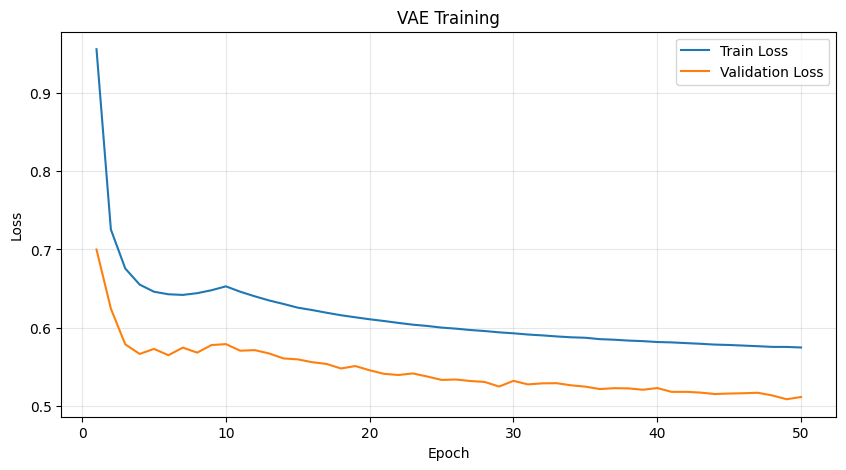

In [42]:
# ============================================================
# 40. TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)


plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "VAE Training"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Ячейка 40 — Recon и KL

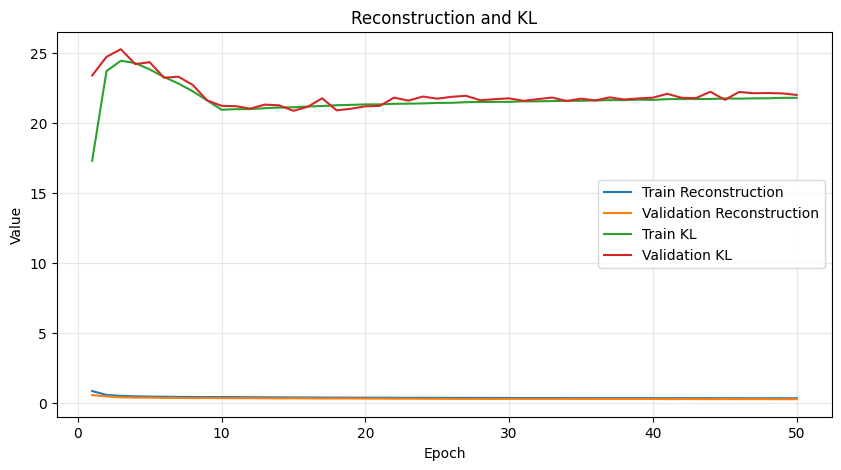

In [43]:
# ============================================================
# 41. RECONSTRUCTION + KL
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_recon"],
    label="Train Reconstruction"
)


plt.plot(
    history_df["epoch"],
    history_df["val_recon"],
    label="Validation Reconstruction"
)


plt.plot(
    history_df["epoch"],
    history_df["train_kl"],
    label="Train KL"
)


plt.plot(
    history_df["epoch"],
    history_df["val_kl"],
    label="Validation KL"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Value"
)

plt.title(
    "Reconstruction and KL"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

Ячейка 41 — статистика latent space

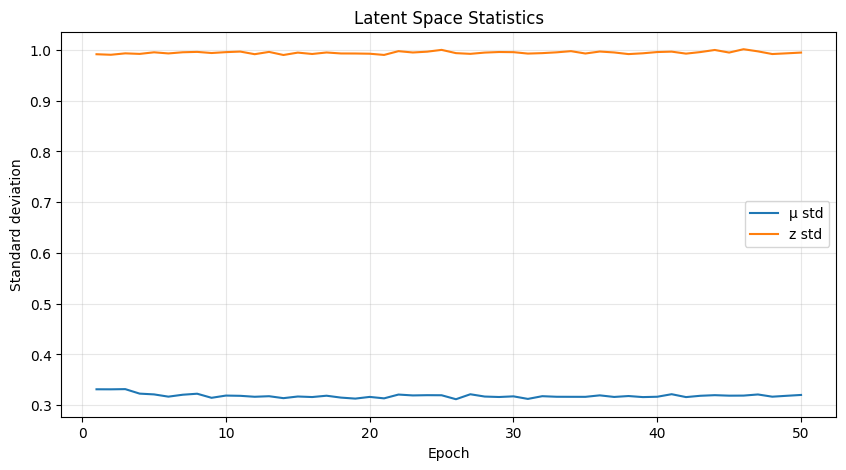

In [44]:
# ============================================================
# 42. LATENT SPACE STATISTICS
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["mu_std"],
    label="μ std"
)


plt.plot(
    history_df["epoch"],
    history_df["z_std"],
    label="z std"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Standard deviation"
)

plt.title(
    "Latent Space Statistics"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [50]:
# ============================================================
# ГЕНЕРАЦИЯ 5000 МОЛЕКУЛ ИЗ ОБУЧЕННОГО TRANSFORMER VAE
# ============================================================

import os
import random
import numpy as np
import torch
from rdkit import Chem
from rdkit import RDLogger
import selfies as sf

RDLogger.DisableLog("rdApp.*")


# ============================================================
# НАСТРОЙКИ
# ============================================================

import os

CHECKPOINT_DIR = "checkpoints_vae"
CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "vae_best_transformer_properties.pt"
)

print(CHECKPOINT_PATH)
print(os.path.exists(CHECKPOINT_PATH))

N_SAMPLES = 5000
SEED = 42

# Максимальная длина последовательности
MAX_LEN = 66

# Размер латентного пространства
LATENT_DIM = 128

# Специальные токены
PAD_IDX = 0
START_IDX = 1
END_IDX = 2
UNK_IDX = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("ГЕНЕРАЦИЯ МОЛЕКУЛ")
print("=" * 70)

print(f"Device:       {DEVICE}")
print(f"Checkpoint:   {CHECKPOINT_PATH}")
print(f"N samples:    {N_SAMPLES}")
print(f"Latent dim:   {LATENT_DIM}")
print(f"Max length:   {MAX_LEN}")


# ============================================================
# SEED
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# ПРОВЕРКА CHECKPOINT
# ============================================================

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint не найден:\n{CHECKPOINT_PATH}"
    )

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("\nCheckpoint загружен.")

if isinstance(checkpoint, dict):
    print("Ключи checkpoint:")
    print(list(checkpoint.keys()))


# ============================================================
# ЗАГРУЗКА ВЕСОВ
# ============================================================

# Предполагается, что объект model уже создан
# точно с той же архитектурой, с которой был обучен checkpoint.

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print("\nЗагружен: model_state_dict")

elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["state_dict"]
    )

    print("\nЗагружен: state_dict")

else:

    # Если checkpoint представляет собой непосредственно
    # state_dict модели
    model.load_state_dict(checkpoint)

    print("\nЗагружен checkpoint как state_dict")


model = model.to(DEVICE)
model.eval()

print("\nМодель переведена в evaluation mode.")


# ============================================================
# ПРОВЕРКА РАЗМЕРА СЛОВАРЯ
# ============================================================

VOCAB_SIZE = model.decoder.embedding.num_embeddings

print(f"Vocabulary size: {VOCAB_SIZE}")


# ============================================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ:
# ПОЛУЧЕНИЕ TOKEN -> SELFIES
# ============================================================

# ВАЖНО:
# В твоём notebook должна существовать переменная idx_to_token
# или аналогичная таблица индексов токенов.
#
# Если у тебя она называется иначе, замени idx_to_token ниже.


def tokens_to_selfies(token_ids, idx_to_token):
    """
    Преобразование последовательности индексов
    в строку SELFIES.
    """

    tokens = []

    for idx in token_ids:

        idx = int(idx)

        if idx == END_IDX:
            break

        if idx in (PAD_IDX, START_IDX):
            continue

        token = idx_to_token.get(idx, "<UNK>")

        if token == "<UNK>":
            return None

        tokens.append(token)

    if len(tokens) == 0:
        return None

    return "".join(tokens)


# ============================================================
# ГЕНЕРАЦИЯ ОДНОЙ ПАРТИИ
# ============================================================

@torch.no_grad()
def generate_batch(
    model,
    z,
    max_len=MAX_LEN
):
    """
    Автогрегрессивная генерация SELFIES
    из латентных векторов z.
    """

    batch_size = z.size(0)

    # Начинаем с <START>
    generated = torch.full(
        (batch_size, 1),
        START_IDX,
        dtype=torch.long,
        device=DEVICE
    )

    finished = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=DEVICE
    )

    for step in range(max_len - 1):

        # Transformer Decoder
        logits = model.decoder(
            generated,
            z
        )

        # Берём прогноз следующего токена
        next_token_logits = logits[:, -1, :]

        # Greedy/temperature sampling
        # ------------------------------------------------
        # Для генерации новых молекул используем sampling,
        # а не argmax.
        # ------------------------------------------------

        temperature = 1.0

        probs = torch.softmax(
            next_token_logits / temperature,
            dim=-1
        )

        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        # Для уже завершённых последовательностей
        # принудительно оставляем PAD
        next_token = torch.where(
            finished.unsqueeze(1),
            torch.full_like(next_token, PAD_IDX),
            next_token
        )

        generated = torch.cat(
            [generated, next_token],
            dim=1
        )

        finished |= (
            next_token.squeeze(1) == END_IDX
        )

        # Если все последовательности завершены
        if finished.all():
            break

    return generated


# ============================================================
# ГЕНЕРАЦИЯ 5000 МОЛЕКУЛ
# ============================================================

BATCH_SIZE_GEN = 256

all_token_sequences = []

print("\nНачинаем генерацию...")
print("-" * 70)

with torch.no_grad():

    for start in range(0, N_SAMPLES, BATCH_SIZE_GEN):

        current_batch = min(
            BATCH_SIZE_GEN,
            N_SAMPLES - start
        )

        # ----------------------------------------------------
        # z ~ N(0, I)
        # ----------------------------------------------------

        z = torch.randn(
            current_batch,
            LATENT_DIM,
            device=DEVICE
        )

        # ----------------------------------------------------
        # Генерация
        # ----------------------------------------------------

        generated_tokens = generate_batch(
            model,
            z
        )

        all_token_sequences.extend(
            generated_tokens.cpu().tolist()
        )

        done = start + current_batch

        if done % 1024 < BATCH_SIZE_GEN or done == N_SAMPLES:
            print(
                f"Generated: {done:5d} / {N_SAMPLES}"
            )


print("-" * 70)
print("Генерация завершена.")


# ============================================================
# SELFIES
# ============================================================

generated_selfies = []

for token_ids in all_token_sequences:

    selfies_string = tokens_to_selfies(
        token_ids,
        idx_to_token
    )

    generated_selfies.append(
        selfies_string
    )


# ============================================================
# SELFIES → SMILES
# ============================================================

generated_smiles = []
valid_smiles = []

invalid_selfies = 0

for selfies_string in generated_selfies:

    if selfies_string is None:
        generated_smiles.append(None)
        invalid_selfies += 1
        continue

    try:

        smiles = sf.decoder(
            selfies_string
        )

        generated_smiles.append(smiles)

        # RDKit validation
        mol = Chem.MolFromSmiles(smiles)

        if mol is not None:
            valid_smiles.append(smiles)

    except Exception:

        generated_smiles.append(None)


# ============================================================
# CANONICAL SMILES
# ============================================================

canonical_smiles = []

for smiles in valid_smiles:

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:

        canonical = Chem.MolToSmiles(
            mol,
            canonical=True
        )

        canonical_smiles.append(
            canonical
        )


# ============================================================
# УНИКАЛЬНОСТЬ
# ============================================================

unique_smiles = set(canonical_smiles)


# ============================================================
# СТАТИСТИКА
# ============================================================

n_generated = len(generated_selfies)
n_valid = len(valid_smiles)
n_unique = len(unique_smiles)

validity = (
    100 * n_valid / n_generated
    if n_generated > 0 else 0
)

uniqueness = (
    100 * n_unique / n_valid
    if n_valid > 0 else 0
)


# ============================================================
# РЕЗУЛЬТАТ
# ============================================================

print()
print("=" * 70)
print("РЕЗУЛЬТАТЫ ГЕНЕРАЦИИ")
print("=" * 70)

print(f"Всего сгенерировано:       {n_generated}")
print(f"Валидных SMILES:            {n_valid}")
print(f"Уникальных молекул:         {n_unique}")
print()
print(f"Validity:                    {validity:.2f}%")
print(f"Uniqueness:                  {uniqueness:.2f}%")

print()
print("=" * 70)
print("ПРИМЕРЫ СГЕНЕРИРОВАННЫХ МОЛЕКУЛ")
print("=" * 70)

for i, smiles in enumerate(canonical_smiles[:20], 1):

    print(f"{i:2d}. {smiles}")

checkpoints_vae\vae_best_transformer_properties.pt
True
ГЕНЕРАЦИЯ МОЛЕКУЛ
Device:       cuda
Checkpoint:   checkpoints_vae\vae_best_transformer_properties.pt
N samples:    5000
Latent dim:   128
Max length:   66

Checkpoint загружен.
Ключи checkpoint:
['epoch', 'best_val_loss', 'history', 'model_state_dict', 'optimizer_state_dict', 'latent_dim', 'embed_dim', 'num_heads', 'num_layers', 'ff_dim', 'dropout', 'max_len', 'vocab_size', 'vocab', 'token_to_idx', 'idx_to_token', 'feature_names', 'property_dim', 'property_scaler']

Загружен: model_state_dict

Модель переведена в evaluation mode.
Vocabulary size: 109

Начинаем генерацию...
----------------------------------------------------------------------
Generated:  1024 / 5000
Generated:  2048 / 5000
Generated:  3072 / 5000
Generated:  4096 / 5000
Generated:  5000 / 5000
----------------------------------------------------------------------
Генерация завершена.

РЕЗУЛЬТАТЫ ГЕНЕРАЦИИ
Всего сгенерировано:       5000
Валидных SMILES:          

In [52]:
# ============================================================
# ОЦЕНКА 5000 СГЕНЕРИРОВАННЫХ МОЛЕКУЛ
# SELFIES → SMILES → RDKit
#
# Метрики:
#   1. Validity
#   2. Uniqueness
#   3. Novelty относительно TRAIN
#   4. Lipinski
#   5. Veber
#   6. PAINS
#   7. Все фильтры одновременно
#   8. Физико-химические дескрипторы
#   9. Novel + All filters
#
# ВАЖНО:
# TRAIN берётся из уже существующего scaffold split:
# df_vae.iloc[train_indices]
#
# Повторная каноникализация всего датасета НЕ выполняется.
# ============================================================

import os
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import (
    Descriptors,
    Lipinski,
    Crippen,
    QED,
    rdMolDescriptors,
    FilterCatalog,
    RDConfig
)

# ------------------------------------------------------------
# Отключаем сообщения RDKit
# ------------------------------------------------------------

RDLogger.DisableLog("rdApp.*")


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

N_GENERATED = 5000

OUTPUT_DIR = "generated_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 70)
print("ОЦЕНКА СГЕНЕРИРОВАННЫХ МОЛЕКУЛ")
print("=" * 70)


# ============================================================
# 2. ПРОВЕРКА GENERATED_SMILES
# ============================================================

# Здесь предполагается, что после генерации уже существует:
#
# generated_smiles
#
# Если у тебя переменная называется иначе,
# замени её здесь.

if "generated_smiles" not in globals():
    raise NameError(
        "Переменная 'generated_smiles' не найдена. "
        "Сначала необходимо выполнить генерацию молекул."
    )


generated_smiles_all = list(generated_smiles)

print(f"\nПолучено SMILES: {len(generated_smiles_all):,}")

if len(generated_smiles_all) != N_GENERATED:
    print(
        f"ВНИМАНИЕ: ожидалось {N_GENERATED:,}, "
        f"получено {len(generated_smiles_all):,}"
    )


# ============================================================
# 3. VALIDITY
# ============================================================

print("\n" + "=" * 70)
print("1. VALIDITY")
print("=" * 70)

valid_smiles = []
invalid_smiles = []

valid_mols = []

for smiles in generated_smiles_all:

    if smiles is None:
        invalid_smiles.append(smiles)
        continue

    try:
        mol = Chem.MolFromSmiles(smiles)

        if mol is not None:
            valid_smiles.append(smiles)
            valid_mols.append(mol)
        else:
            invalid_smiles.append(smiles)

    except Exception:
        invalid_smiles.append(smiles)


n_total = len(generated_smiles_all)
n_valid = len(valid_smiles)
n_invalid = len(invalid_smiles)

validity = (
    100.0 * n_valid / n_total
    if n_total > 0
    else 0.0
)

print(f"Всего сгенерировано: {n_total:,}")
print(f"Валидных SMILES:     {n_valid:,}")
print(f"Невалидных SMILES:   {n_invalid:,}")
print(f"Validity:             {validity:.2f}%")


# ============================================================
# 4. УНИКАЛЬНОСТЬ
# ============================================================

print("\n" + "=" * 70)
print("2. UNIQUENESS")
print("=" * 70)

# Важно:
# Здесь используем canonical SMILES только для СГЕНЕРИРОВАННЫХ
# молекул.
#
# Это позволяет определить химически одинаковые молекулы,
# записанные разными SMILES.

generated_canonical = []

for smiles in valid_smiles:

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        canonical = Chem.MolToSmiles(
            mol,
            canonical=True
        )
        generated_canonical.append(canonical)


generated_unique = list(
    dict.fromkeys(generated_canonical)
)

n_generated_unique = len(generated_unique)

uniqueness = (
    100.0 * n_generated_unique / n_valid
    if n_valid > 0
    else 0.0
)

print(f"Валидных молекул:    {n_valid:,}")
print(f"Уникальных молекул:  {n_generated_unique:,}")
print(f"Uniqueness:           {uniqueness:.2f}%")


# ============================================================
# 5. TRAIN SET ДЛЯ NOVELTY
# ============================================================

print("\n" + "=" * 70)
print("3. TRAIN SET ДЛЯ NOVELTY")
print("=" * 70)

# ------------------------------------------------------------
# ВАЖНО
# ------------------------------------------------------------
#
# Мы НЕ используем весь df_vae.
#
# Модель обучалась только на:
#
#     df_vae.iloc[train_indices]
#
# Поэтому novelty необходимо считать относительно TRAIN.
#
# Также НЕ выполняем повторную каноникализацию всего TRAIN,
# если smiles в df_vae уже подготовлены в canonical форме.
# ------------------------------------------------------------

train_smiles = (
    df_vae
    .iloc[train_indices]["smiles"]
    .dropna()
    .astype(str)
)

train_canonical = set(train_smiles)

print(f"Молекул в TRAIN: {len(train_canonical):,}")


# ============================================================
# 6. NOVELTY
# ============================================================

print("\n" + "=" * 70)
print("4. NOVELTY")
print("=" * 70)

novel_generated = [
    smiles
    for smiles in generated_unique
    if smiles not in train_canonical
]

n_novel = len(novel_generated)

novelty = (
    100.0 * n_novel / n_generated_unique
    if n_generated_unique > 0
    else 0.0
)

print(f"Уникальных сгенерировано: {n_generated_unique:,}")
print(f"Новых относительно TRAIN: {n_novel:,}")
print(f"Novelty:                   {novelty:.2f}%")


# ============================================================
# 7. MOLECULE OBJECTS
# ============================================================

print("\n" + "=" * 70)
print("5. ПОДГОТОВКА RDKit MOLECULE OBJECTS")
print("=" * 70)

unique_mols = []

valid_unique_smiles = []

for smiles in generated_unique:

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        valid_unique_smiles.append(smiles)
        unique_mols.append(mol)


print(
    f"Уникальных молекул для анализа: "
    f"{len(unique_mols):,}"
)


# ============================================================
# 8. LIPINSKI
# ============================================================

def check_lipinski(mol):
    """
    Проверка основных критериев Lipinski.

    Используем:
        MW    <= 500
        LogP  <= 5
        HBD   <= 5
        HBA   <= 10

    Допускается не более одного нарушения.
    """

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)

    violations = 0

    if mw > 500:
        violations += 1

    if logp > 5:
        violations += 1

    if hbd > 5:
        violations += 1

    if hba > 10:
        violations += 1

    return violations <= 1


lipinski_pass = np.array(
    [
        check_lipinski(mol)
        for mol in unique_mols
    ],
    dtype=bool
)


# ============================================================
# 9. VEBER
# ============================================================

def check_veber(mol):
    """
    Критерии Veber:

        TPSA <= 140 Å²
        Rotatable Bonds <= 10
    """

    tpsa = rdMolDescriptors.CalcTPSA(mol)

    rotatable_bonds = (
        Lipinski.NumRotatableBonds(mol)
    )

    return (
        tpsa <= 140
        and rotatable_bonds <= 10
    )


veber_pass = np.array(
    [
        check_veber(mol)
        for mol in unique_mols
    ],
    dtype=bool
)


# ============================================================
# 10. PAINS
# ============================================================

print("\n" + "=" * 70)
print("6. PAINS")
print("=" * 70)

params = FilterCatalog.FilterCatalogParams()

params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS
)

pains_catalog = FilterCatalog.FilterCatalog(params)


def check_pains(mol):
    """
    True = молекула не содержит PAINS-паттернов.
    """

    return not pains_catalog.HasMatch(mol)


pains_pass = np.array(
    [
        check_pains(mol)
        for mol in unique_mols
    ],
    dtype=bool
)


# ============================================================
# 11. ВСЕ ФИЛЬТРЫ
# ============================================================

all_filters_pass = (
    lipinski_pass
    & veber_pass
    & pains_pass
)


# ============================================================
# 12. СТАТИСТИКА ФИЛЬТРОВ
# ============================================================

n_unique = len(unique_mols)

n_lipinski = int(lipinski_pass.sum())
n_veber = int(veber_pass.sum())
n_pains = int(pains_pass.sum())
n_all = int(all_filters_pass.sum())


def percentage(value, total):
    if total == 0:
        return 0.0
    return 100.0 * value / total


print("\n" + "=" * 70)
print("7. РЕЗУЛЬТАТЫ ФИЛЬТРАЦИИ")
print("=" * 70)

print(
    f"Lipinski:     "
    f"{n_lipinski:,} / {n_unique:,} "
    f"({percentage(n_lipinski, n_unique):.2f}%)"
)

print(
    f"Veber:        "
    f"{n_veber:,} / {n_unique:,} "
    f"({percentage(n_veber, n_unique):.2f}%)"
)

print(
    f"PAINS-free:   "
    f"{n_pains:,} / {n_unique:,} "
    f"({percentage(n_pains, n_unique):.2f}%)"
)

print(
    f"All filters:  "
    f"{n_all:,} / {n_unique:,} "
    f"({percentage(n_all, n_unique):.2f}%)"
)


# ============================================================
# 13. NOVEL + ALL FILTERS
# ============================================================

novel_set = set(novel_generated)

novel_all_filters = []

for smiles, passes in zip(
    valid_unique_smiles,
    all_filters_pass
):

    if passes and smiles in novel_set:
        novel_all_filters.append(smiles)


n_novel_all = len(novel_all_filters)

novel_all_percent = percentage(
    n_novel_all,
    n_unique
)

print("\n" + "=" * 70)
print("8. NOVEL + ALL FILTERS")
print("=" * 70)

print(
    f"Новые + все фильтры: "
    f"{n_novel_all:,} / {n_unique:,} "
    f"({novel_all_percent:.2f}%)"
)


# ============================================================
# 14. ДЕСКРИПТОРЫ
# ============================================================

print("\n" + "=" * 70)
print("9. РАСЧЁТ ДЕСКРИПТОРОВ")
print("=" * 70)

descriptor_rows = []

for smiles, mol in zip(
    valid_unique_smiles,
    unique_mols
):

    descriptor_rows.append(
        {
            "canonical_smiles": smiles,

            "MW": Descriptors.MolWt(mol),

            "LogP": Crippen.MolLogP(mol),

            "TPSA": rdMolDescriptors.CalcTPSA(mol),

            "HBD": Lipinski.NumHDonors(mol),

            "HBA": Lipinski.NumHAcceptors(mol),

            "RotatableBonds":
                Lipinski.NumRotatableBonds(mol),

            "Rings":
                rdMolDescriptors.CalcNumRings(mol),

            "AromaticRings":
                rdMolDescriptors.CalcNumAromaticRings(mol),

            "FractionCSP3":
                rdMolDescriptors.CalcFractionCSP3(mol),

            "QED":
                QED.qed(mol),

            "Lipinski":
                bool(
                    lipinski_pass[
                        len(descriptor_rows)
                    ]
                ),

            "Veber":
                bool(
                    veber_pass[
                        len(descriptor_rows)
                    ]
                ),

            "PAINS_free":
                bool(
                    pains_pass[
                        len(descriptor_rows)
                    ]
                ),

            "All_filters":
                bool(
                    all_filters_pass[
                        len(descriptor_rows)
                    ]
                ),

            "Novel":
                smiles in novel_set,

            "Novel_All_filters":
                (
                    smiles in novel_set
                    and all_filters_pass[
                        len(descriptor_rows)
                    ]
                )
        }
    )


results_df = pd.DataFrame(
    descriptor_rows
)


# ============================================================
# 15. SAS
# ============================================================

print("\nРасчёт SAS...")

try:

    import sys

    sa_score_path = os.path.join(
        RDConfig.RDContribDir,
        "SA_Score"
    )

    if sa_score_path not in sys.path:
        sys.path.append(sa_score_path)

    import sascorer

    results_df["SAS"] = [
        sascorer.calculateScore(mol)
        for mol in unique_mols
    ]

    print("SAS рассчитан.")

except Exception as e:

    print(
        f"Не удалось рассчитать SAS: {e}"
    )

    results_df["SAS"] = np.nan


# ============================================================
# 16. ИТОГОВАЯ ТАБЛИЦА
# ============================================================

print("\n" + "=" * 70)
print("10. ИТОГОВАЯ СТАТИСТИКА ДЕСКРИПТОРОВ")
print("=" * 70)

descriptor_columns = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3",
    "QED",
    "SAS"
]

print(
    results_df[
        descriptor_columns
    ].describe().T[
        [
            "mean",
            "std",
            "min",
            "50%",
            "max"
        ]
    ].round(3)
)


# ============================================================
# 17. СОХРАНЕНИЕ ПОЛНЫХ РЕЗУЛЬТАТОВ
# ============================================================

full_results_path = os.path.join(
    OUTPUT_DIR,
    "generated_5000_evaluation.csv"
)

results_df.to_csv(
    full_results_path,
    index=False
)

print("\n" + "=" * 70)
print("11. СОХРАНЕНИЕ")
print("=" * 70)

print(
    f"Полная таблица:\n"
    f"{full_results_path}"
)


# ============================================================
# 18. NOVEL MOLECULES
# ============================================================

novel_df = results_df[
    results_df["Novel"]
].copy()

novel_path = os.path.join(
    OUTPUT_DIR,
    "generated_novel.csv"
)

novel_df.to_csv(
    novel_path,
    index=False
)

print(
    f"\nНовые молекулы:\n"
    f"{novel_path}"
)


# ============================================================
# 19. NOVEL + ALL FILTERS
# ============================================================

novel_all_df = results_df[
    results_df["Novel_All_filters"]
].copy()

novel_all_path = os.path.join(
    OUTPUT_DIR,
    "generated_novel_all_filters.csv"
)

novel_all_df.to_csv(
    novel_all_path,
    index=False
)

print(
    f"Новые + все фильтры:\n"
    f"{novel_all_path}"
)


# ============================================================
# 20. PARQUET
# ============================================================

try:

    parquet_path = os.path.join(
        OUTPUT_DIR,
        "generated_5000_evaluation.parquet"
    )

    results_df.to_parquet(
        parquet_path,
        index=False
    )

    print(
        f"\nParquet:\n"
        f"{parquet_path}"
    )

except Exception as e:

    print(
        f"\nParquet не сохранён: {e}"
    )


# ============================================================
# 21. КОРОТКИЙ ФИНАЛЬНЫЙ ОТЧЁТ
# ============================================================

print("\n")
print("=" * 70)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 70)

print(
    f"Всего сгенерировано:       {n_total:,}"
)

print(
    f"Валидных SMILES:            {n_valid:,} "
    f"({validity:.2f}%)"
)

print(
    f"Уникальных молекул:         {n_unique:,} "
    f"({uniqueness:.2f}%)"
)

print(
    f"Новых относительно TRAIN:   {n_novel:,} "
    f"({novelty:.2f}%)"
)

print(
    f"Lipinski:                   {n_lipinski:,} "
    f"({percentage(n_lipinski, n_unique):.2f}%)"
)

print(
    f"Veber:                      {n_veber:,} "
    f"({percentage(n_veber, n_unique):.2f}%)"
)

print(
    f"PAINS-free:                 {n_pains:,} "
    f"({percentage(n_pains, n_unique):.2f}%)"
)

print(
    f"All filters:                {n_all:,} "
    f"({percentage(n_all, n_unique):.2f}%)"
)

print(
    f"Novel + all filters:        {n_novel_all:,} "
    f"({novel_all_percent:.2f}%)"
)

print("=" * 70)
print("ОЦЕНКА ЗАВЕРШЕНА")
print("=" * 70)

ОЦЕНКА СГЕНЕРИРОВАННЫХ МОЛЕКУЛ

Получено SMILES: 5,000

1. VALIDITY
Всего сгенерировано: 5,000
Валидных SMILES:     5,000
Невалидных SMILES:   0
Validity:             100.00%

2. UNIQUENESS
Валидных молекул:    5,000
Уникальных молекул:  5,000
Uniqueness:           100.00%

3. TRAIN SET ДЛЯ NOVELTY
Молекул в TRAIN: 189,238

4. NOVELTY
Уникальных сгенерировано: 5,000
Новых относительно TRAIN: 5,000
Novelty:                   100.00%

5. ПОДГОТОВКА RDKit MOLECULE OBJECTS
Уникальных молекул для анализа: 5,000

6. PAINS

7. РЕЗУЛЬТАТЫ ФИЛЬТРАЦИИ
Lipinski:     4,996 / 5,000 (99.92%)
Veber:        4,897 / 5,000 (97.94%)
PAINS-free:   4,913 / 5,000 (98.26%)
All filters:  4,813 / 5,000 (96.26%)

8. NOVEL + ALL FILTERS
Новые + все фильтры: 4,813 / 5,000 (96.26%)

9. РАСЧЁТ ДЕСКРИПТОРОВ

Расчёт SAS...
SAS рассчитан.

10. ИТОГОВАЯ СТАТИСТИКА ДЕСКРИПТОРОВ
                   mean     std     min      50%      max
MW              326.421  63.797  31.034  326.780  590.747
LogP              2.116   1.

УГЛУБЛЁННАЯ ОЦЕНКА ГЕНЕРАТОРА

Уникальных generated molecules: 5,000

1. ПОДГОТОВКА GENERATED MOLECULES
Valid generated molecules: 5,000

2. TRAIN SET
TRAIN molecules: 189,238

Подготовка TRAIN molecules...


TRAIN → RDKit: 100%|██████████| 189238/189238 [00:49<00:00, 3800.65it/s]


Valid TRAIN molecules: 189,238

3. ДЕСКРИПТОРЫ GENERATED


Generated descriptors: 100%|██████████| 5000/5000 [00:11<00:00, 447.71it/s]



4. ДЕСКРИПТОРЫ TRAIN


...

TRAIN fingerprints: 189,238

7. TRAIN SUBSET ДЛЯ STRUCTURAL NOVELTY
Используется случайная выборка TRAIN: 25,000 / 189,238

8. СТРУКТУРНАЯ НОВИЗНА
Для каждой generated molecule ищется наиболее похожая молекула TRAIN.

Начинаем расчёт Max Tanimoto...


Generated → TRAIN similarity: 100%|██████████| 5000/5000 [00:59<00:00, 83.54it/s]



Расчёт завершён за 1.00 мин.

9. MAX TANIMOTO TO TRAIN
      mean: 0.3273
       std: 0.0832
       min: 0.0714
       25%: 0.2667
    median: 0.3194
       75%: 0.3770
       90%: 0.4355
       95%: 0.4737
       99%: 0.5574
       max: 0.7500

10. СТРУКТУРНАЯ БЛИЗОСТЬ
Max Tanimoto >= 0.4: 911 / 5,000 (18.22%)
Max Tanimoto >= 0.5: 173 / 5,000 (3.46%)
Max Tanimoto >= 0.6: 23 / 5,000 (0.46%)
Max Tanimoto >= 0.7: 5 / 5,000 (0.10%)
Max Tanimoto >= 0.8: 0 / 5,000 (0.00%)
Max Tanimoto >= 0.9: 0 / 5,000 (0.00%)

11. INTERNAL DIVERSITY
Количество молекул: 5,000
Всего пар: 12,497,500


Internal diversity: 100%|██████████| 4999/4999 [00:02<00:00, 2049.77it/s]



Средняя Tanimoto similarity: 0.1055
Internal diversity: 0.8945

12. ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ

13. НАИБОЛЕЕ ПОХОЖИЕ К TRAIN
                                    canonical_smiles  Max_Tanimoto_to_TRAIN                                     Nearest_TRAIN_SMILES      QED      MW     LogP  TPSA
                         CCC(=O)NC(=S)NCc1ccc(Cl)cc1               0.750000                               CCC(=O)NC(=S)NCc1ccc(C)cc1 0.815370 256.758  2.24070 41.13
      Cc1ccc(F)cc1NC(=O)[C@H]1CC[C@@H](C)O[C@H](C)C1               0.711111               Cc1cc(F)ccc1NC(=O)C1C[C@@H](C)O[C@@H](C)C1 0.896744 279.355  3.66632 38.33
      O=C1CCc2cc(O[C@H]3CC[C@@H](C(=O)[O-])C3)ccc2N1               0.708333                  O=C1CCc2cc(O[C@@H]3CC[C@@H](O)C3)ccc2N1 0.886680 274.296  0.86870 78.46
             CCOc1ccc(NC(=O)c2cccc(CN3CCCC3=O)c2)cc1               0.706897                 CCOc1ccc(C(=O)NCc2cccc(CN3CCCC3=O)c2)cc1 0.877370 338.407  3.46000 58.64
          C[C@@H](CO)NC(=O)C(=O)Nc1cccc(OC(F)(F)F)c1

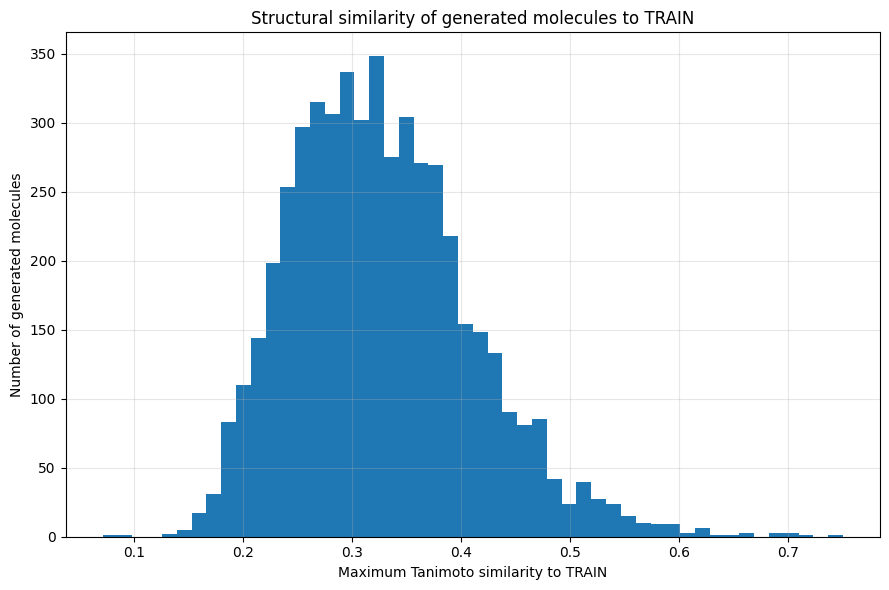

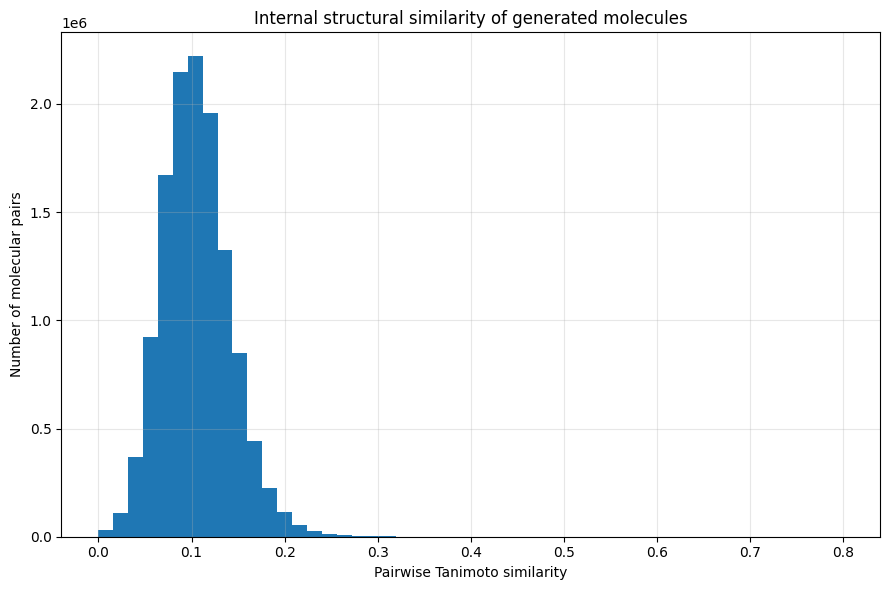

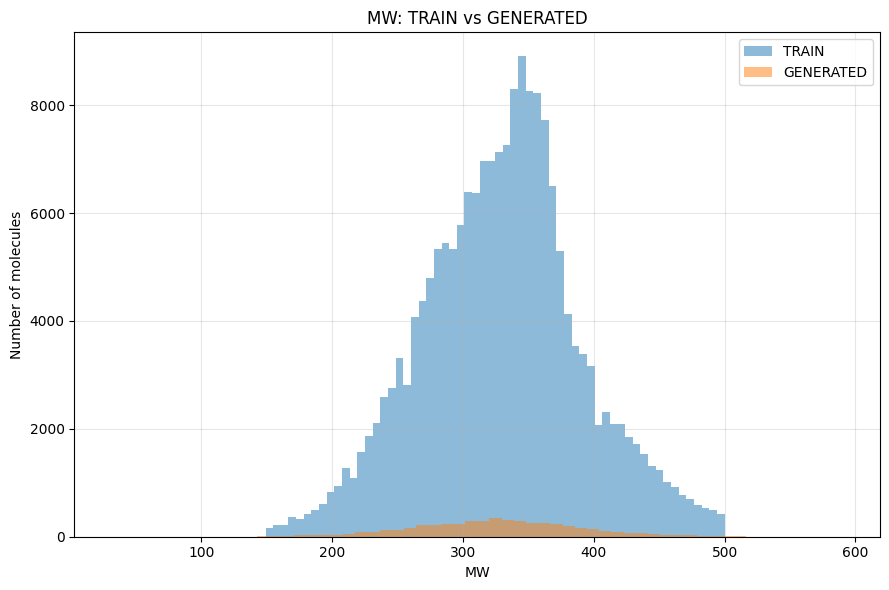

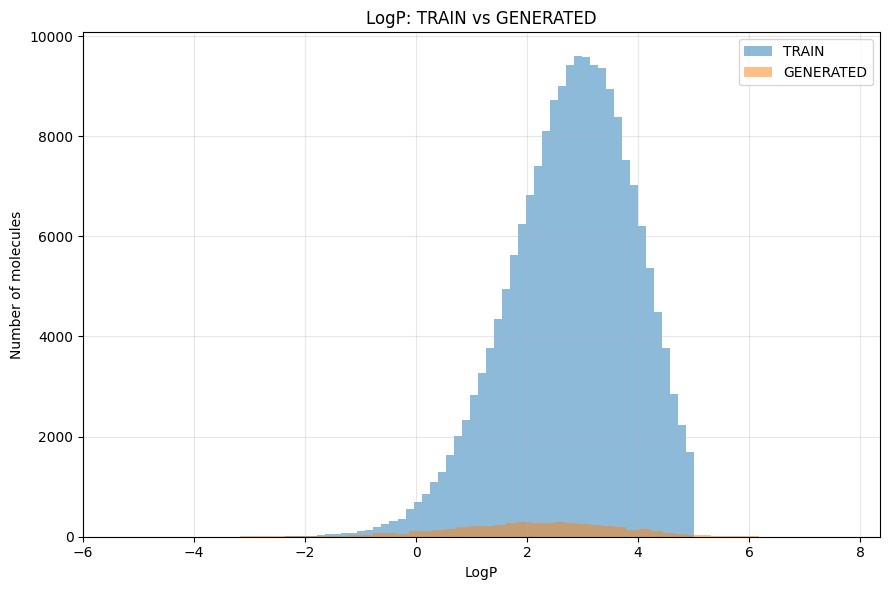

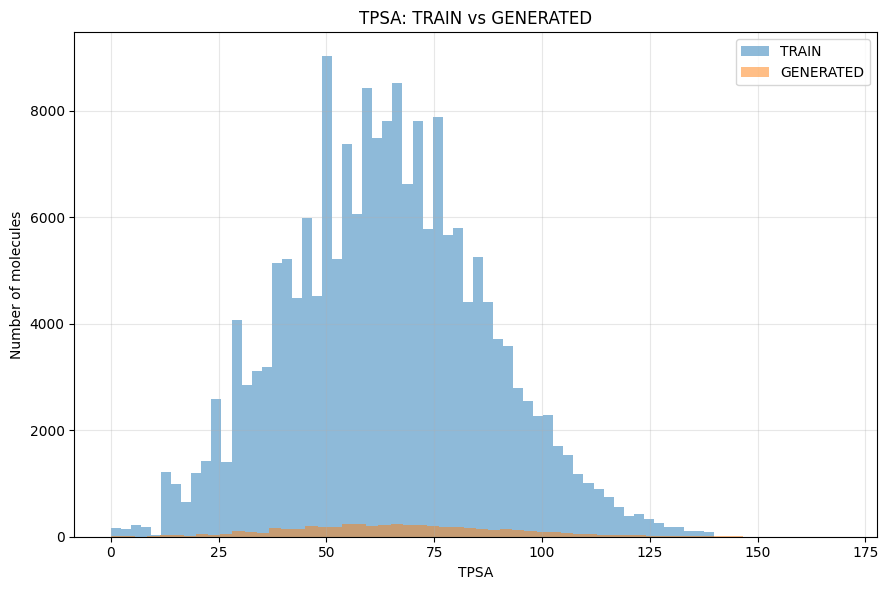

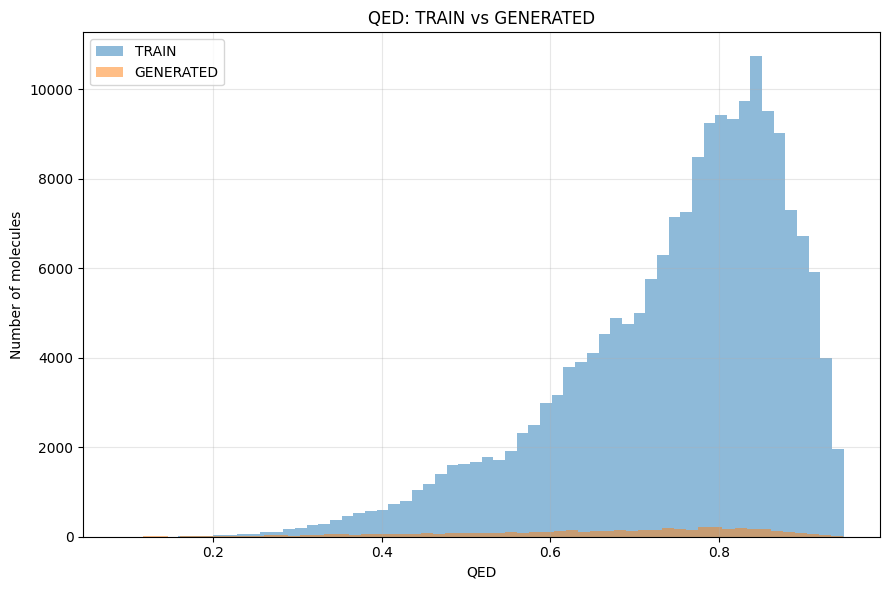

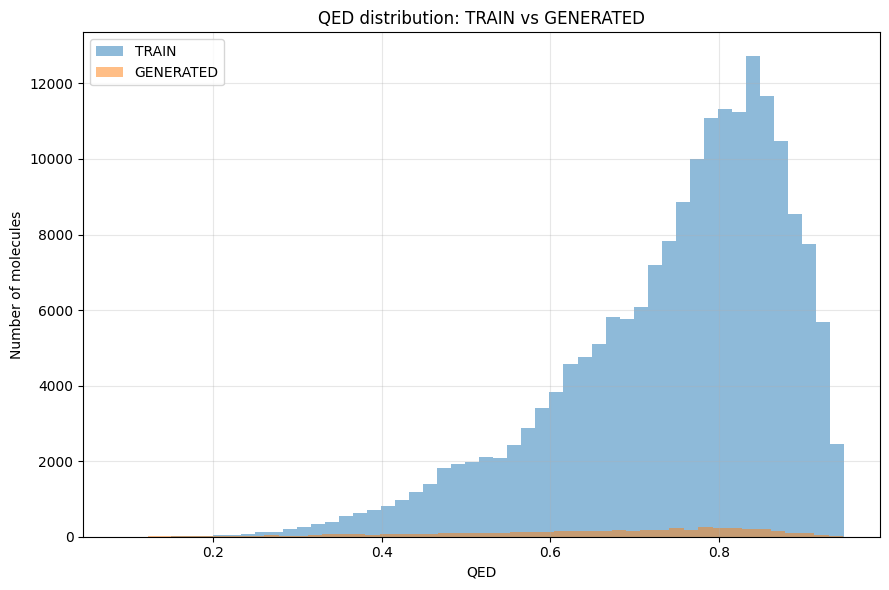



ФИНАЛЬНАЯ ОЦЕНКА ГЕНЕРАТОРА

Generated molecules:              5,000
TRAIN molecules:                  189,238

Exact novelty:                    100.00%
Mean Max Tanimoto to TRAIN:      0.3273
Median Max Tanimoto to TRAIN:    0.3194
95% Max Tanimoto:                0.4737
Maximum Tanimoto:                 0.7500

Mean internal Tanimoto:            0.1055
Internal diversity:                0.8945


Средние дескрипторы GENERATED:
MW                326.421
LogP                2.116
TPSA               67.406
HBD                 1.493
HBA                 3.911
RotatableBonds      5.223
Rings               2.337
AromaticRings       1.221
FractionCSP3        0.428
QED                 0.656


Средние дескрипторы TRAIN:
MW                329.533
LogP                2.776
TPSA               63.948
HBD                 1.156
HBA                 3.902
RotatableBonds      4.562
Rings               2.721
AromaticRings       1.819
FractionCSP3        0.418
QED                 0.748

ФАЙЛЫ СОХРАНЕНЫ

In [53]:
# ============================================================
# УГЛУБЛЁННАЯ ОЦЕНКА ГЕНЕРАТОРА
#
# TRAIN vs GENERATED
#
# 1. Сравнение дескрипторов
# 2. Morgan fingerprints
# 3. Структурная новизна
# 4. Max Tanimoto similarity к TRAIN
# 5. Internal diversity
# 6. Распределение similarity
# 7. QED / SAS
# 8. Графики
# 9. Сохранение результатов
#
# Используются уже существующие:
#
#   df_vae
#   train_indices
#   results_df
#   generated_unique
#
# Повторная генерация молекул НЕ выполняется.
# Повторная каноникализация TRAIN НЕ выполняется.
# ============================================================


import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import (
    Descriptors,
    Lipinski,
    Crippen,
    QED,
    rdMolDescriptors
)
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import (
    BulkTanimotoSimilarity
)

# ------------------------------------------------------------
# Отключаем сообщения RDKit
# ------------------------------------------------------------

RDLogger.DisableLog("rdApp.*")

warnings.filterwarnings("ignore")


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

OUTPUT_DIR = "generated_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Размер TRAIN, используемый для оценки структурной новизны
#
# 25000 = быстрый приблизительный вариант
#
# None = весь TRAIN, точный вариант
# ------------------------------------------------------------

APPROXIMATE_TRAIN_SIZE = 25_000

# ------------------------------------------------------------
# Morgan fingerprint
# ------------------------------------------------------------

MORGAN_RADIUS = 2
MORGAN_N_BITS = 2048

# ------------------------------------------------------------
# Internal diversity
#
# Полный расчёт для 5000 молекул:
#
# 5000 * 4999 / 2 ≈ 12.5 млн сравнений
#
# Это допустимо, но может занять некоторое время.
# ------------------------------------------------------------

CALCULATE_INTERNAL_DIVERSITY = True

# ------------------------------------------------------------
# Максимальное количество пар для расчёта,
# если нужно ограничить время.
#
# None = все пары
# ------------------------------------------------------------

MAX_INTERNAL_PAIRS = None

# ------------------------------------------------------------
# Seed
# ------------------------------------------------------------

SEED = 42

rng = np.random.default_rng(SEED)


# ============================================================
# 2. ПРОВЕРКА НЕОБХОДИМЫХ ПЕРЕМЕННЫХ
# ============================================================

required_variables = [
    "df_vae",
    "train_indices",
    "results_df",
    "generated_unique"
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise NameError(
        "Не найдены необходимые переменные: "
        + ", ".join(missing_variables)
    )


# ============================================================
# 3. ПОДГОТОВКА GENERATED
# ============================================================

print("=" * 70)
print("УГЛУБЛЁННАЯ ОЦЕНКА ГЕНЕРАТОРА")
print("=" * 70)

generated_smiles = list(generated_unique)

print(
    f"\nУникальных generated molecules: "
    f"{len(generated_smiles):,}"
)


# ============================================================
# 4. RDKit MOLECULES GENERATED
# ============================================================

print("\n" + "=" * 70)
print("1. ПОДГОТОВКА GENERATED MOLECULES")
print("=" * 70)

generated_mols = []

generated_valid_smiles = []

for smiles in generated_smiles:

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:

        generated_mols.append(mol)
        generated_valid_smiles.append(smiles)


print(
    f"Valid generated molecules: "
    f"{len(generated_mols):,}"
)


# ============================================================
# 5. TRAIN
# ============================================================

print("\n" + "=" * 70)
print("2. TRAIN SET")
print("=" * 70)

# ------------------------------------------------------------
# Используем уже существующий scaffold split.
#
# НИКАКОЙ повторной каноникализации TRAIN.
# ------------------------------------------------------------

train_smiles = (
    df_vae
    .iloc[train_indices]["smiles"]
    .dropna()
    .astype(str)
    .tolist()
)

print(
    f"TRAIN molecules: "
    f"{len(train_smiles):,}"
)


# ============================================================
# 6. RDKit MOLECULES TRAIN
# ============================================================

print("\nПодготовка TRAIN molecules...")

train_mols = []

train_valid_smiles = []

for smiles in tqdm(
    train_smiles,
    desc="TRAIN → RDKit"
):

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:

        train_mols.append(mol)
        train_valid_smiles.append(smiles)


print(
    f"Valid TRAIN molecules: "
    f"{len(train_mols):,}"
)


# ============================================================
# 7. DESCRIPTOR FUNCTION
# ============================================================

def calculate_descriptors(mol):
    """
    Расчёт основных физико-химических дескрипторов.
    """

    return {
        "MW":
            Descriptors.MolWt(mol),

        "LogP":
            Crippen.MolLogP(mol),

        "TPSA":
            rdMolDescriptors.CalcTPSA(mol),

        "HBD":
            Lipinski.NumHDonors(mol),

        "HBA":
            Lipinski.NumHAcceptors(mol),

        "RotatableBonds":
            Lipinski.NumRotatableBonds(mol),

        "Rings":
            rdMolDescriptors.CalcNumRings(mol),

        "AromaticRings":
            rdMolDescriptors.CalcNumAromaticRings(mol),

        "FractionCSP3":
            rdMolDescriptors.CalcFractionCSP3(mol),

        "QED":
            QED.qed(mol)
    }


# ============================================================
# 8. GENERATED DESCRIPTORS
# ============================================================

print("\n" + "=" * 70)
print("3. ДЕСКРИПТОРЫ GENERATED")
print("=" * 70)

generated_descriptor_rows = []

for smiles, mol in tqdm(
    zip(
        generated_valid_smiles,
        generated_mols
    ),
    total=len(generated_mols),
    desc="Generated descriptors"
):

    row = calculate_descriptors(mol)

    row["canonical_smiles"] = smiles

    generated_descriptor_rows.append(row)


generated_desc_df = pd.DataFrame(
    generated_descriptor_rows
)

generated_desc_df = generated_desc_df[
    [
        "canonical_smiles",
        "MW",
        "LogP",
        "TPSA",
        "HBD",
        "HBA",
        "RotatableBonds",
        "Rings",
        "AromaticRings",
        "FractionCSP3",
        "QED"
    ]
]


# ============================================================
# 9. TRAIN DESCRIPTORS
# ============================================================

print("\n" + "=" * 70)
print("4. ДЕСКРИПТОРЫ TRAIN")
print("=" * 70)

train_descriptor_rows = []

for smiles, mol in tqdm(
    zip(
        train_valid_smiles,
        train_mols
    ),
    total=len(train_mols),
    desc="TRAIN descriptors"
):

    row = calculate_descriptors(mol)

    row["canonical_smiles"] = smiles

    train_descriptor_rows.append(row)


train_desc_df = pd.DataFrame(
    train_descriptor_rows
)

train_desc_df = train_desc_df[
    [
        "canonical_smiles",
        "MW",
        "LogP",
        "TPSA",
        "HBD",
        "HBA",
        "RotatableBonds",
        "Rings",
        "AromaticRings",
        "FractionCSP3",
        "QED"
    ]
]


# ============================================================
# 10. DESCRIPTOR COMPARISON
# ============================================================

descriptor_columns = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3",
    "QED"
]


comparison_rows = []

for column in descriptor_columns:

    train_values = train_desc_df[column]
    generated_values = generated_desc_df[column]

    comparison_rows.append(
        {
            "Descriptor": column,

            "TRAIN_mean":
                train_values.mean(),

            "TRAIN_std":
                train_values.std(),

            "TRAIN_median":
                train_values.median(),

            "TRAIN_min":
                train_values.min(),

            "TRAIN_max":
                train_values.max(),

            "GENERATED_mean":
                generated_values.mean(),

            "GENERATED_std":
                generated_values.std(),

            "GENERATED_median":
                generated_values.median(),

            "GENERATED_min":
                generated_values.min(),

            "GENERATED_max":
                generated_values.max()
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 11. ПЕЧАТЬ СРАВНЕНИЯ
# ============================================================

print("\n" + "=" * 70)
print("5. TRAIN vs GENERATED")
print("=" * 70)

print(
    comparison_df.round(3).to_string(
        index=False
    )
)


# ============================================================
# 12. MORGAN FINGERPRINT GENERATOR
# ============================================================

print("\n" + "=" * 70)
print("6. MORGAN FINGERPRINTS")
print("=" * 70)

morgan_generator = (
    rdFingerprintGenerator.GetMorganGenerator(
        radius=MORGAN_RADIUS,
        fpSize=MORGAN_N_BITS
    )
)


# ============================================================
# 13. GENERATED FINGERPRINTS
# ============================================================

print("\nСоздание fingerprints GENERATED...")

generated_fps = [
    morgan_generator.GetFingerprint(mol)
    for mol in tqdm(
        generated_mols,
        desc="Generated fingerprints"
    )
]

print(
    f"Generated fingerprints: "
    f"{len(generated_fps):,}"
)


# ============================================================
# 14. TRAIN FINGERPRINTS
# ============================================================

print("\nСоздание fingerprints TRAIN...")

train_fps = [
    morgan_generator.GetFingerprint(mol)
    for mol in tqdm(
        train_mols,
        desc="TRAIN fingerprints"
    )
]

print(
    f"TRAIN fingerprints: "
    f"{len(train_fps):,}"
)


# ============================================================
# 15. ВЫБОР TRAIN ДЛЯ СТРУКТУРНОЙ НОВИЗНЫ
# ============================================================

print("\n" + "=" * 70)
print("7. TRAIN SUBSET ДЛЯ STRUCTURAL NOVELTY")
print("=" * 70)

if APPROXIMATE_TRAIN_SIZE is None:

    train_fps_similarity = train_fps

    train_smiles_similarity = (
        train_valid_smiles
    )

    print(
        "Используется ВЕСЬ TRAIN."
    )

else:

    subset_size = min(
        APPROXIMATE_TRAIN_SIZE,
        len(train_fps)
    )

    subset_indices = rng.choice(
        len(train_fps),
        size=subset_size,
        replace=False
    )

    train_fps_similarity = [
        train_fps[i]
        for i in subset_indices
    ]

    train_smiles_similarity = [
        train_valid_smiles[i]
        for i in subset_indices
    ]

    print(
        f"Используется случайная выборка TRAIN: "
        f"{subset_size:,} / {len(train_fps):,}"
    )


# ============================================================
# 16. MAX TANIMOTO К TRAIN
# ============================================================

print("\n" + "=" * 70)
print("8. СТРУКТУРНАЯ НОВИЗНА")
print("=" * 70)

print(
    "Для каждой generated molecule "
    "ищется наиболее похожая молекула TRAIN."
)

print(
    "\nНачинаем расчёт Max Tanimoto..."
)

start_time = time.time()

max_similarities = []
nearest_train_smiles = []

for generated_fp in tqdm(
    generated_fps,
    desc="Generated → TRAIN similarity"
):

    similarities = BulkTanimotoSimilarity(
        generated_fp,
        train_fps_similarity
    )

    max_index = int(
        np.argmax(similarities)
    )

    max_similarity = float(
        similarities[max_index]
    )

    max_similarities.append(
        max_similarity
    )

    nearest_train_smiles.append(
        train_smiles_similarity[max_index]
    )


similarity_time = (
    time.time() - start_time
)

print(
    f"\nРасчёт завершён за "
    f"{similarity_time / 60:.2f} мин."
)


# ============================================================
# 17. ДОБАВЛЯЕМ STRUCTURAL NOVELTY
# ============================================================

generated_desc_df[
    "Max_Tanimoto_to_TRAIN"
] = max_similarities

generated_desc_df[
    "Nearest_TRAIN_SMILES"
] = nearest_train_smiles


# ============================================================
# 18. СТАТИСТИКА MAX TANIMOTO
# ============================================================

similarity_array = np.asarray(
    max_similarities
)


similarity_statistics = {
    "mean":
        np.mean(similarity_array),

    "std":
        np.std(similarity_array),

    "min":
        np.min(similarity_array),

    "25%":
        np.percentile(
            similarity_array,
            25
        ),

    "median":
        np.median(similarity_array),

    "75%":
        np.percentile(
            similarity_array,
            75
        ),

    "90%":
        np.percentile(
            similarity_array,
            90
        ),

    "95%":
        np.percentile(
            similarity_array,
            95
        ),

    "99%":
        np.percentile(
            similarity_array,
            99
        ),

    "max":
        np.max(similarity_array)
}


print("\n" + "=" * 70)
print("9. MAX TANIMOTO TO TRAIN")
print("=" * 70)

for key, value in similarity_statistics.items():

    print(
        f"{key:>10}: "
        f"{value:.4f}"
    )


# ============================================================
# 19. КАТЕГОРИИ СТРУКТУРНОЙ БЛИЗОСТИ
# ============================================================

print("\n" + "=" * 70)
print("10. СТРУКТУРНАЯ БЛИЗОСТЬ")
print("=" * 70)

thresholds = [
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

for threshold in thresholds:

    count = int(
        np.sum(
            similarity_array >= threshold
        )
    )

    percent = (
        100.0 * count
        / len(similarity_array)
    )

    print(
        f"Max Tanimoto >= {threshold:.1f}: "
        f"{count:,} / {len(similarity_array):,} "
        f"({percent:.2f}%)"
    )


# ============================================================
# 20. INTERNAL DIVERSITY
# ============================================================

if CALCULATE_INTERNAL_DIVERSITY:

    print("\n" + "=" * 70)
    print("11. INTERNAL DIVERSITY")
    print("=" * 70)

    n_generated = len(generated_fps)

    total_pairs = (
        n_generated
        * (n_generated - 1)
        // 2
    )

    print(
        f"Количество молекул: "
        f"{n_generated:,}"
    )

    print(
        f"Всего пар: "
        f"{total_pairs:,}"
    )

    if (
        MAX_INTERNAL_PAIRS is not None
        and MAX_INTERNAL_PAIRS < total_pairs
    ):

        print(
            f"Используется выборка "
            f"{MAX_INTERNAL_PAIRS:,} пар."
        )

        pair_i = rng.integers(
            0,
            n_generated,
            size=MAX_INTERNAL_PAIRS
        )

        pair_j = rng.integers(
            0,
            n_generated,
            size=MAX_INTERNAL_PAIRS
        )

        mask = pair_i != pair_j

        pair_i = pair_i[mask]
        pair_j = pair_j[mask]

        internal_similarities = []

        for i, j in tqdm(
            zip(pair_i, pair_j),
            total=len(pair_i),
            desc="Internal similarity"
        ):

            similarity = (
                BulkTanimotoSimilarity(
                    generated_fps[i],
                    [generated_fps[j]]
                )[0]
            )

            internal_similarities.append(
                similarity
            )

    else:

        internal_similarities = []

        for i in tqdm(
            range(n_generated - 1),
            desc="Internal diversity"
        ):

            similarities = BulkTanimotoSimilarity(
                generated_fps[i],
                generated_fps[i + 1:]
            )

            internal_similarities.extend(
                similarities
            )


    internal_similarities = np.asarray(
        internal_similarities,
        dtype=np.float32
    )

    mean_internal_similarity = (
        internal_similarities.mean()
    )

    internal_diversity = (
        1.0
        - mean_internal_similarity
    )

    print(
        f"\nСредняя Tanimoto similarity: "
        f"{mean_internal_similarity:.4f}"
    )

    print(
        f"Internal diversity: "
        f"{internal_diversity:.4f}"
    )

else:

    internal_similarities = None

    mean_internal_similarity = np.nan

    internal_diversity = np.nan


# ============================================================
# 21. РАСШИРЯЕМ GENERATED RESULTS
# ============================================================

print("\n" + "=" * 70)
print("12. ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 70)

# ------------------------------------------------------------
# Добавляем результаты предыдущего анализа:
#
# Lipinski
# Veber
# PAINS
# All filters
# Novel
# Novel_All_filters
#
# ------------------------------------------------------------

filter_columns = [
    "Lipinski",
    "Veber",
    "PAINS_free",
    "All_filters",
    "Novel",
    "Novel_All_filters"
]


available_filter_columns = [
    column
    for column in filter_columns
    if column in results_df.columns
]


# ------------------------------------------------------------
# Создаём lookup по canonical SMILES
# ------------------------------------------------------------

results_lookup = (
    results_df
    .set_index("canonical_smiles")
)


for column in available_filter_columns:

    generated_desc_df[column] = (
        generated_desc_df[
            "canonical_smiles"
        ]
        .map(
            results_lookup[column]
        )
    )


# ============================================================
# 22. СОРТИРОВКА ПО СТРУКТУРНОЙ НОВИЗНЕ
# ============================================================

generated_desc_df = (
    generated_desc_df
    .sort_values(
        "Max_Tanimoto_to_TRAIN",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. НАИБОЛЕЕ ПОХОЖИЕ МОЛЕКУЛЫ
# ============================================================

print("\n" + "=" * 70)
print("13. НАИБОЛЕЕ ПОХОЖИЕ К TRAIN")
print("=" * 70)

similar_molecules = (
    generated_desc_df[
        [
            "canonical_smiles",
            "Max_Tanimoto_to_TRAIN",
            "Nearest_TRAIN_SMILES",
            "QED",
            "MW",
            "LogP",
            "TPSA"
        ]
    ]
    .head(20)
)

print(
    similar_molecules.to_string(
        index=False
    )
)


# ============================================================
# 24. НАИБОЛЕЕ СТРУКТУРНО ОТДАЛЁННЫЕ
# ============================================================

print("\n" + "=" * 70)
print("14. НАИБОЛЕЕ СТРУКТУРНО ОТДАЛЁННЫЕ")
print("=" * 70)

most_novel_molecules = (
    generated_desc_df[
        [
            "canonical_smiles",
            "Max_Tanimoto_to_TRAIN",
            "QED",
            "MW",
            "LogP",
            "TPSA"
        ]
    ]
    .sort_values(
        "Max_Tanimoto_to_TRAIN",
        ascending=True
    )
    .head(20)
)

print(
    most_novel_molecules.to_string(
        index=False
    )
)


# ============================================================
# 25. СОХРАНЕНИЕ РАСШИРЕННЫХ РЕЗУЛЬТАТОВ
# ============================================================

extended_results_path = os.path.join(
    OUTPUT_DIR,
    "generated_5000_extended_evaluation.csv"
)

generated_desc_df.to_csv(
    extended_results_path,
    index=False
)

print(
    f"\nРасширенные результаты:\n"
    f"{extended_results_path}"
)


# ============================================================
# 26. СОХРАНЕНИЕ TRAIN vs GENERATED
# ============================================================

comparison_path = os.path.join(
    OUTPUT_DIR,
    "train_vs_generated_descriptors.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    f"\nTRAIN vs GENERATED:\n"
    f"{comparison_path}"
)


# ============================================================
# 27. СОХРАНЕНИЕ СТРУКТУРНОЙ НОВИЗНЫ
# ============================================================

novelty_path = os.path.join(
    OUTPUT_DIR,
    "generated_structural_novelty.csv"
)

generated_desc_df[
    [
        "canonical_smiles",
        "Max_Tanimoto_to_TRAIN",
        "Nearest_TRAIN_SMILES"
    ]
].to_csv(
    novelty_path,
    index=False
)

print(
    f"\nStructural novelty:\n"
    f"{novelty_path}"
)


# ============================================================
# 28. ГРАФИКИ
# ============================================================

print("\n" + "=" * 70)
print("15. ПОСТРОЕНИЕ ГРАФИКОВ")
print("=" * 70)


# ============================================================
# 28.1. MAX TANIMOTO DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    similarity_array,
    bins=50
)

plt.xlabel(
    "Maximum Tanimoto similarity to TRAIN"
)

plt.ylabel(
    "Number of generated molecules"
)

plt.title(
    "Structural similarity of generated molecules to TRAIN"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

similarity_plot_path = os.path.join(
    OUTPUT_DIR,
    "max_tanimoto_distribution.png"
)

plt.savefig(
    similarity_plot_path,
    dpi=150
)

plt.show()


# ============================================================
# 28.2. INTERNAL SIMILARITY
# ============================================================

if internal_similarities is not None:

    plt.figure(
        figsize=(9, 6)
    )

    plt.hist(
        internal_similarities,
        bins=50
    )

    plt.xlabel(
        "Pairwise Tanimoto similarity"
    )

    plt.ylabel(
        "Number of molecular pairs"
    )

    plt.title(
        "Internal structural similarity of generated molecules"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    internal_plot_path = os.path.join(
        OUTPUT_DIR,
        "internal_tanimoto_distribution.png"
    )

    plt.savefig(
        internal_plot_path,
        dpi=150
    )

    plt.show()


# ============================================================
# 28.3. DESCRIPTOR DISTRIBUTIONS
# ============================================================

plot_descriptors = [
    "MW",
    "LogP",
    "TPSA",
    "QED"
]


for descriptor in plot_descriptors:

    plt.figure(
        figsize=(9, 6)
    )

    plt.hist(
        train_desc_df[descriptor],
        bins=60,
        alpha=0.5,
        label="TRAIN"
    )

    plt.hist(
        generated_desc_df[descriptor],
        bins=60,
        alpha=0.5,
        label="GENERATED"
    )

    plt.xlabel(
        descriptor
    )

    plt.ylabel(
        "Number of molecules"
    )

    plt.title(
        f"{descriptor}: TRAIN vs GENERATED"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plot_path = os.path.join(
        OUTPUT_DIR,
        f"{descriptor}_train_vs_generated.png"
    )

    plt.savefig(
        plot_path,
        dpi=150
    )

    plt.show()


# ============================================================
# 29. QED DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    train_desc_df["QED"],
    bins=50,
    alpha=0.5,
    label="TRAIN"
)

plt.hist(
    generated_desc_df["QED"],
    bins=50,
    alpha=0.5,
    label="GENERATED"
)

plt.xlabel(
    "QED"
)

plt.ylabel(
    "Number of molecules"
)

plt.title(
    "QED distribution: TRAIN vs GENERATED"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

qed_plot_path = os.path.join(
    OUTPUT_DIR,
    "QED_train_vs_generated.png"
)

plt.savefig(
    qed_plot_path,
    dpi=150
)

plt.show()


# ============================================================
# 30. ФИНАЛЬНАЯ СТАТИСТИКА
# ============================================================

print("\n")
print("=" * 70)
print("ФИНАЛЬНАЯ ОЦЕНКА ГЕНЕРАТОРА")
print("=" * 70)

print(
    f"\nGenerated molecules:"
    f"              {len(generated_mols):,}"
)

print(
    f"TRAIN molecules:"
    f"                  {len(train_mols):,}"
)

print(
    f"\nExact novelty:"
    f"                    100.00%"
)

print(
    f"Mean Max Tanimoto to TRAIN:"
    f"      {similarity_array.mean():.4f}"
)

print(
    f"Median Max Tanimoto to TRAIN:"
    f"    {np.median(similarity_array):.4f}"
)

print(
    f"95% Max Tanimoto:"
    f"                {np.percentile(similarity_array, 95):.4f}"
)

print(
    f"Maximum Tanimoto:"
    f"                 {similarity_array.max():.4f}"
)

if not np.isnan(
    internal_diversity
):

    print(
        f"\nMean internal Tanimoto:"
        f"            {mean_internal_similarity:.4f}"
    )

    print(
        f"Internal diversity:"
        f"                {internal_diversity:.4f}"
    )


print("\n")
print(
    "Средние дескрипторы GENERATED:"
)

print(
    generated_desc_df[
        descriptor_columns
    ]
    .mean()
    .round(3)
    .to_string()
)


print("\n")
print(
    "Средние дескрипторы TRAIN:"
)

print(
    train_desc_df[
        descriptor_columns
    ]
    .mean()
    .round(3)
    .to_string()
)


print("\n" + "=" * 70)
print("ФАЙЛЫ СОХРАНЕНЫ")
print("=" * 70)

print(
    extended_results_path
)

print(
    comparison_path
)

print(
    novelty_path
)

print(
    similarity_plot_path
)

if internal_similarities is not None:

    print(
        internal_plot_path
    )

print("=" * 70)
print("УГЛУБЛЁННАЯ ОЦЕНКА ЗАВЕРШЕНА")
print("=" * 70)

In [54]:
# ============================================================
# ГЛУБОКАЯ ОЦЕНКА ГЕНЕРИРОВАННЫХ МОЛЕКУЛ
# ============================================================
#
# Эксперимент включает:
# 1. Точную структурную новизну относительно ВСЕГО TRAIN
# 2. Max Tanimoto similarity для каждой generated molecule
# 3. Химическую sanity-проверку
# 4. Сравнение распределений дескрипторов TRAIN / GENERATED
# 5. Wasserstein distance
# 6. Сохранение результатов
#
# ВАЖНО:
# SELFIES обеспечивает синтаксическую валидность,
# но RDKit validity != химическая правдоподобность.
#
# ============================================================

import os
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from rdkit import Chem, DataStructs
from rdkit import RDLogger
from rdkit.Chem import (
    Descriptors,
    Crippen,
    Lipinski,
    rdMolDescriptors,
    QED,
    AllChem
)

from scipy.stats import wasserstein_distance


# ============================================================
# 0. НАСТРОЙКИ
# ============================================================

SEED = 42

# Папка результатов
RESULTS_DIR = "generated_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Размер Morgan fingerprint
FP_RADIUS = 2
FP_NBITS = 2048

# Порог структурной близости
SIMILARITY_THRESHOLDS = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Эвристические пороги sanity-check
MIN_HEAVY_ATOMS = 8
MIN_MW = 100.0

# Наиболее распространённые элементы органической химии.
# Это НЕ критерий валидности молекулы, а только диагностический признак.
COMMON_ATOMS = {
    "C", "N", "O", "S", "P",
    "F", "Cl", "Br", "I",
    "B", "Si"
}

# Отключаем сообщения RDKit
RDLogger.DisableLog("rdApp.*")

np.random.seed(SEED)

print("=" * 70)
print("ГЛУБОКАЯ ОЦЕНКА ГЕНЕРИРОВАННЫХ МОЛЕКУЛ")
print("=" * 70)
print(f"Seed: {SEED}")
print(f"Fingerprint: Morgan radius={FP_RADIUS}, nBits={FP_NBITS}")
print()


# ============================================================
# 1. ПРОВЕРКА ВХОДНЫХ ДАННЫХ
# ============================================================

required_vars = [
    "generated_valid_smiles",
    "train_valid_smiles"
]

missing = [
    var for var in required_vars
    if var not in globals()
]

if missing:
    raise RuntimeError(
        "Не найдены необходимые переменные: "
        + ", ".join(missing)
        + "\n"
        "Запустите сначала ячейку генерации/подготовки "
        "generated_valid_smiles и train_valid_smiles."
    )


generated_smiles = list(generated_valid_smiles)
train_smiles = list(train_valid_smiles)

print("Входные данные:")
print(f"TRAIN molecules:     {len(train_smiles):,}")
print(f"GENERATED molecules:  {len(generated_smiles):,}")
print()


# ============================================================
# 2. ПОДГОТОВКА RDKit MOLECULES
# ============================================================

print("=" * 70)
print("1. ПОДГОТОВКА RDKit MOLECULES")
print("=" * 70)

start_time = time.time()

train_mols = []
train_smiles_valid = []

for smi in tqdm(
    train_smiles,
    desc="TRAIN → RDKit",
    unit="mol"
):
    mol = Chem.MolFromSmiles(smi)

    if mol is not None:
        train_mols.append(mol)
        train_smiles_valid.append(smi)


generated_mols = []
generated_smiles_valid = []

for smi in tqdm(
    generated_smiles,
    desc="GENERATED → RDKit",
    unit="mol"
):
    mol = Chem.MolFromSmiles(smi)

    if mol is not None:
        generated_mols.append(mol)
        generated_smiles_valid.append(smi)


print()
print(f"TRAIN valid RDKit:      {len(train_mols):,}")
print(f"GENERATED valid RDKit:  {len(generated_mols):,}")
print(
    f"Время: {time.time() - start_time:.1f} сек."
)
print()


# ============================================================
# 3. MORGAN FINGERPRINTS ДЛЯ ВСЕГО TRAIN
# ============================================================

print("=" * 70)
print("2. MORGAN FINGERPRINTS")
print("=" * 70)

start_time = time.time()

print("Расчёт fingerprint TRAIN...")

train_fps = []

for mol in tqdm(
    train_mols,
    desc="TRAIN fingerprints",
    unit="mol"
):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=FP_RADIUS,
        nBits=FP_NBITS
    )
    train_fps.append(fp)


print("Расчёт fingerprint GENERATED...")

generated_fps = []

for mol in tqdm(
    generated_mols,
    desc="GENERATED fingerprints",
    unit="mol"
):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=FP_RADIUS,
        nBits=FP_NBITS
    )
    generated_fps.append(fp)


print()
print(
    f"Fingerprint TRAIN:     {len(train_fps):,}"
)
print(
    f"Fingerprint GENERATED: {len(generated_fps):,}"
)
print(
    f"Время: {time.time() - start_time:.1f} сек."
)
print()


# ============================================================
# 4. ТОЧНАЯ СТРУКТУРНАЯ НОВИЗНА
# ============================================================
#
# Для КАЖДОЙ generated molecule:
#
#     similarity = max(
#         Tanimoto(generated, every TRAIN molecule)
#     )
#
# Это уже НЕ приближённая оценка по 25 000 TRAIN,
# а поиск по всему TRAIN.
#
# TRAIN ≈ 189k
# GENERATED = 5000
#
# Всего потенциально около 946 млн сравнений.
#
# ============================================================

print("=" * 70)
print("3. ТОЧНАЯ СТРУКТУРНАЯ НОВИЗНА")
print("=" * 70)

print(
    f"Сравнение {len(generated_fps):,} generated "
    f"с {len(train_fps):,} TRAIN molecules."
)

print(
    "Это может занять несколько минут."
)
print()

start_time = time.time()

max_similarities = np.zeros(
    len(generated_fps),
    dtype=np.float32
)

nearest_train_indices = np.zeros(
    len(generated_fps),
    dtype=np.int32
)

for i, gen_fp in enumerate(
    tqdm(
        generated_fps,
        desc="Exact TRAIN search",
        unit="mol"
    )
):
    similarities = DataStructs.BulkTanimotoSimilarity(
        gen_fp,
        train_fps
    )

    similarities = np.asarray(
        similarities,
        dtype=np.float32
    )

    max_idx = int(np.argmax(similarities))

    max_similarities[i] = similarities[max_idx]
    nearest_train_indices[i] = max_idx


elapsed = time.time() - start_time

print()
print(f"Время exact search: {elapsed / 60:.2f} мин.")
print()


# ============================================================
# 5. СТАТИСТИКА MAX TANIMOTO
# ============================================================

print("=" * 70)
print("4. MAX TANIMOTO → TRAIN")
print("=" * 70)

sim_series = pd.Series(max_similarities)

print(
    sim_series.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).to_string()
)

print()

for threshold in SIMILARITY_THRESHOLDS:

    count = int(
        np.sum(max_similarities >= threshold)
    )

    percentage = (
        count / len(max_similarities) * 100
    )

    print(
        f"Max Tanimoto >= {threshold:.1f}: "
        f"{count:,} / {len(max_similarities):,} "
        f"({percentage:.2f}%)"
    )

print()


# ============================================================
# 6. СТРУКТУРНО САМЫЕ БЛИЗКИЕ MOLECULES
# ============================================================

print("=" * 70)
print("5. НАИБОЛЕЕ ПОХОЖИЕ МОЛЕКУЛЫ")
print("=" * 70)

nearest_train_smiles = [
    train_smiles_valid[idx]
    for idx in nearest_train_indices
]

novelty_df = pd.DataFrame({
    "generated_smiles": generated_smiles_valid,
    "max_tanimoto_to_train": max_similarities,
    "nearest_train_smiles": nearest_train_smiles
})

top_similar = (
    novelty_df
    .sort_values(
        "max_tanimoto_to_train",
        ascending=False
    )
    .head(20)
)

for i, row in top_similar.reset_index(drop=True).iterrows():

    print(
        f"\n{i + 1}. "
        f"Tanimoto = "
        f"{row['max_tanimoto_to_train']:.4f}"
    )

    print(
        f"GENERATED: {row['generated_smiles']}"
    )

    print(
        f"TRAIN:     {row['nearest_train_smiles']}"
    )


print()


# ============================================================
# 7. ХИМИЧЕСКАЯ SANITY CHECK
# ============================================================
#
# Здесь мы НЕ объявляем молекулы "плохими".
#
# Проверяем диагностические признаки:
#
# - число фрагментов
# - общий формальный заряд
# - количество заряженных атомов
# - радикальные электроны
# - число тяжёлых атомов
# - молекулярную массу
# - необычные элементы
#
# Это именно диагностический анализ.
# ============================================================

print("=" * 70)
print("6. CHEMICAL SANITY CHECK")
print("=" * 70)


sanity_rows = []

for smi, mol in tqdm(
    zip(
        generated_smiles_valid,
        generated_mols
    ),
    total=len(generated_mols),
    desc="Chemical sanity",
    unit="mol"
):

    # --------------------------------------------------------
    # Фрагменты
    # --------------------------------------------------------

    fragments = Chem.GetMolFrags(
        mol,
        asMols=False,
        sanitizeFrags=False
    )

    n_fragments = len(fragments)

    # --------------------------------------------------------
    # Формальный заряд
    # --------------------------------------------------------

    formal_charge = Chem.GetFormalCharge(mol)

    positive_atoms = 0
    negative_atoms = 0
    radical_electrons = 0

    atom_symbols = []

    for atom in mol.GetAtoms():

        charge = atom.GetFormalCharge()

        if charge > 0:
            positive_atoms += 1

        if charge < 0:
            negative_atoms += 1

        radical_electrons += (
            atom.GetNumRadicalElectrons()
        )

        atom_symbols.append(
            atom.GetSymbol()
        )

    unique_atoms = sorted(
        set(atom_symbols)
    )

    unusual_atoms = sorted(
        set(unique_atoms) - COMMON_ATOMS
    )

    # --------------------------------------------------------
    # Дескрипторы
    # --------------------------------------------------------

    mw = Descriptors.MolWt(mol)

    heavy_atoms = mol.GetNumHeavyAtoms()

    logp = Crippen.MolLogP(mol)

    qed = QED.qed(mol)

    # --------------------------------------------------------
    # Эвристические признаки
    # --------------------------------------------------------

    disconnected = n_fragments > 1

    charged = formal_charge != 0

    has_radicals = radical_electrons > 0

    unusual_element = len(unusual_atoms) > 0

    very_small = (
        heavy_atoms < MIN_HEAVY_ATOMS
        or mw < MIN_MW
    )

    sanity_rows.append({
        "smiles": smi,

        "n_fragments": n_fragments,
        "disconnected": disconnected,

        "formal_charge": formal_charge,
        "positive_atoms": positive_atoms,
        "negative_atoms": negative_atoms,

        "radical_electrons": radical_electrons,
        "has_radicals": has_radicals,

        "heavy_atoms": heavy_atoms,
        "MW": mw,

        "LogP": logp,
        "QED": qed,

        "atom_symbols": ",".join(unique_atoms),
        "unusual_atoms": ",".join(unusual_atoms),
        "has_unusual_atoms": unusual_element,

        "very_small": very_small
    })


sanity_df = pd.DataFrame(sanity_rows)


# ============================================================
# 8. СТАТИСТИКА SANITY CHECK
# ============================================================

print()
print("CHEMICAL SANITY SUMMARY")
print("-" * 70)

n_total = len(sanity_df)

n_disconnected = int(
    sanity_df["disconnected"].sum()
)

n_charged = int(
    (sanity_df["formal_charge"] != 0).sum()
)

n_radicals = int(
    sanity_df["has_radicals"].sum()
)

n_unusual = int(
    sanity_df["has_unusual_atoms"].sum()
)

n_small = int(
    sanity_df["very_small"].sum()
)


def print_sanity_stat(name, count):

    print(
        f"{name:<35} "
        f"{count:,} / {n_total:,} "
        f"({count / n_total * 100:.2f}%)"
    )


print_sanity_stat(
    "Disconnected molecules",
    n_disconnected
)

print_sanity_stat(
    "Non-zero formal charge",
    n_charged
)

print_sanity_stat(
    "Radical electrons",
    n_radicals
)

print_sanity_stat(
    "Unusual atom symbols",
    n_unusual
)

print_sanity_stat(
    f"Very small (<{MIN_HEAVY_ATOMS} heavy atoms or <{MIN_MW} Da)",
    n_small
)

print()


# ============================================================
# 9. СПИСОК НЕОБЫЧНЫХ МОЛЕКУЛ
# ============================================================

print("=" * 70)
print("7. ПРИМЕРЫ MOLECULES С SANITY FLAGS")
print("=" * 70)


flag_columns = [
    "disconnected",
    "has_radicals",
    "has_unusual_atoms",
    "very_small"
]

flagged_mask = (
    sanity_df[flag_columns]
    .any(axis=1)
)


flagged_df = (
    sanity_df[flagged_mask]
    .copy()
)

print(
    f"Молекул с хотя бы одним "
    f"диагностическим flag: "
    f"{len(flagged_df):,} / {n_total:,} "
    f"({len(flagged_df) / n_total * 100:.2f}%)"
)

print()


if len(flagged_df) > 0:

    print("Первые 20 примеров:")
    print("-" * 70)

    display_columns = [
        "smiles",
        "n_fragments",
        "formal_charge",
        "radical_electrons",
        "heavy_atoms",
        "MW",
        "atom_symbols",
        "unusual_atoms"
    ]

    print(
        flagged_df[
            display_columns
        ]
        .head(20)
        .to_string(index=False)
    )


print()


# ============================================================
# 10. РАСПРЕДЕЛЕНИЯ ДЕСКРИПТОРОВ
# ============================================================

print("=" * 70)
print("8. DESCRIPTOR DISTRIBUTIONS")
print("=" * 70)


DESCRIPTOR_NAMES = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "Rings",
    "AromaticRings",
    "FractionCSP3",
    "QED"
]


def calculate_descriptors(mols):

    rows = []

    for mol in tqdm(
        mols,
        desc="Descriptors",
        unit="mol"
    ):

        rows.append({

            "MW": Descriptors.MolWt(mol),

            "LogP": Crippen.MolLogP(mol),

            "TPSA": rdMolDescriptors.CalcTPSA(mol),

            "HBD": Lipinski.NumHDonors(mol),

            "HBA": Lipinski.NumHAcceptors(mol),

            "RotatableBonds":
                Lipinski.NumRotatableBonds(mol),

            "Rings":
                rdMolDescriptors.CalcNumRings(mol),

            "AromaticRings":
                rdMolDescriptors.CalcNumAromaticRings(mol),

            "FractionCSP3":
                rdMolDescriptors.CalcFractionCSP3(mol),

            "QED":
                QED.qed(mol)
        })

    return pd.DataFrame(rows)


print("Расчёт дескрипторов GENERATED...")

generated_desc_df = calculate_descriptors(
    generated_mols
)

print()

print("Расчёт дескрипторов TRAIN...")

train_desc_df = calculate_descriptors(
    train_mols
)

print()


# ============================================================
# 11. TRAIN VS GENERATED
# ============================================================

print("=" * 70)
print("9. TRAIN vs GENERATED")
print("=" * 70)

comparison_rows = []

for descriptor in DESCRIPTOR_NAMES:

    train_values = (
        train_desc_df[descriptor]
        .dropna()
        .values
    )

    generated_values = (
        generated_desc_df[descriptor]
        .dropna()
        .values
    )

    train_mean = np.mean(train_values)
    generated_mean = np.mean(generated_values)

    train_std = np.std(
        train_values,
        ddof=1
    )

    generated_std = np.std(
        generated_values,
        ddof=1
    )

    train_median = np.median(
        train_values
    )

    generated_median = np.median(
        generated_values
    )

    comparison_rows.append({

        "Descriptor": descriptor,

        "TRAIN_mean": train_mean,
        "GENERATED_mean": generated_mean,

        "TRAIN_std": train_std,
        "GENERATED_std": generated_std,

        "TRAIN_median": train_median,
        "GENERATED_median": generated_median
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()


# ============================================================
# 12. WASSERSTEIN DISTANCE
# ============================================================
#
# Чем меньше значение, тем ближе распределения
# TRAIN и GENERATED по данному дескриптору.
#
# Это не "оценка качества" сама по себе,
# а количественная мера различия распределений.
# ============================================================

print("=" * 70)
print("10. WASSERSTEIN DISTANCE")
print("=" * 70)

wasserstein_rows = []

for descriptor in DESCRIPTOR_NAMES:

    train_values = (
        train_desc_df[descriptor]
        .dropna()
        .values
    )

    generated_values = (
        generated_desc_df[descriptor]
        .dropna()
        .values
    )

    distance = wasserstein_distance(
        train_values,
        generated_values
    )

    wasserstein_rows.append({

        "Descriptor": descriptor,

        "Wasserstein_distance":
            distance
    })


wasserstein_df = pd.DataFrame(
    wasserstein_rows
)

print(
    wasserstein_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print()


# ============================================================
# 13. ОБЪЕДИНЯЕМ ВСЕ РЕЗУЛЬТАТЫ
# ============================================================

print("=" * 70)
print("11. ФИНАЛЬНАЯ ТАБЛИЦА")
print("=" * 70)


final_df = novelty_df.copy()

final_df = final_df.merge(
    sanity_df,
    left_on="generated_smiles",
    right_on="smiles",
    how="left"
)

final_df.drop(
    columns=["smiles"],
    inplace=True
)


# Добавляем descriptor information
final_df = pd.concat(
    [
        final_df.reset_index(drop=True),
        generated_desc_df.reset_index(drop=True)
            .add_prefix("generated_")
    ],
    axis=1
)


# ============================================================
# 14. КАТЕГОРИИ СТРУКТУРНОЙ НОВИЗНЫ
# ============================================================

final_df["similarity_category"] = pd.cut(
    final_df["max_tanimoto_to_train"],
    bins=[
        -np.inf,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        np.inf
    ],
    labels=[
        "<0.4",
        "0.4-0.5",
        "0.5-0.6",
        "0.6-0.7",
        "0.7-0.8",
        "0.8-0.9",
        ">=0.9"
    ]
)


# ============================================================
# 15. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================

print("=" * 70)
print("12. СОХРАНЕНИЕ")
print("=" * 70)


novelty_path = os.path.join(
    RESULTS_DIR,
    "generated_structural_novelty_exact.csv"
)

sanity_path = os.path.join(
    RESULTS_DIR,
    "generated_chemical_sanity.csv"
)

comparison_path = os.path.join(
    RESULTS_DIR,
    "train_vs_generated_descriptors.csv"
)

wasserstein_path = os.path.join(
    RESULTS_DIR,
    "descriptor_wasserstein.csv"
)

final_path = os.path.join(
    RESULTS_DIR,
    "generated_full_evaluation.csv"
)


novelty_df.to_csv(
    novelty_path,
    index=False
)

sanity_df.to_csv(
    sanity_path,
    index=False
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

wasserstein_df.to_csv(
    wasserstein_path,
    index=False
)

final_df.to_csv(
    final_path,
    index=False
)


# Parquet для удобной дальнейшей работы
try:

    final_parquet_path = os.path.join(
        RESULTS_DIR,
        "generated_full_evaluation.parquet"
    )

    final_df.to_parquet(
        final_parquet_path,
        index=False
    )

    parquet_status = final_parquet_path

except Exception as e:

    parquet_status = (
        f"Parquet не сохранён: {e}"
    )


print()
print("Сохранено:")
print(f"1. {novelty_path}")
print(f"2. {sanity_path}")
print(f"3. {comparison_path}")
print(f"4. {wasserstein_path}")
print(f"5. {final_path}")
print(f"6. {parquet_status}")
print()


# ============================================================
# 16. ФИНАЛЬНЫЙ ОТЧЁТ
# ============================================================

print("=" * 70)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("=" * 70)

print()
print("ДАННЫЕ")
print("-" * 70)
print(
    f"TRAIN molecules:       {len(train_mols):,}"
)
print(
    f"GENERATED molecules:    {len(generated_mols):,}"
)

print()
print("СТРУКТУРНАЯ НОВИЗНА")
print("-" * 70)

print(
    f"Mean Max Tanimoto:      "
    f"{np.mean(max_similarities):.4f}"
)

print(
    f"Median Max Tanimoto:    "
    f"{np.median(max_similarities):.4f}"
)

print(
    f"95% percentile:         "
    f"{np.percentile(max_similarities, 95):.4f}"
)

print(
    f"99% percentile:         "
    f"{np.percentile(max_similarities, 99):.4f}"
)

print(
    f"Maximum:                "
    f"{np.max(max_similarities):.4f}"
)

print()

for threshold in SIMILARITY_THRESHOLDS:

    count = int(
        np.sum(
            max_similarities >= threshold
        )
    )

    print(
        f"Similarity >= {threshold:.1f}: "
        f"{count:,} "
        f"({count / len(max_similarities) * 100:.2f}%)"
    )


print()
print("CHEMICAL SANITY")
print("-" * 70)

print(
    f"Disconnected:           "
    f"{n_disconnected:,} "
    f"({n_disconnected / n_total * 100:.2f}%)"
)

print(
    f"Charged:                "
    f"{n_charged:,} "
    f"({n_charged / n_total * 100:.2f}%)"
)

print(
    f"Radicals:               "
    f"{n_radicals:,} "
    f"({n_radicals / n_total * 100:.2f}%)"
)

print(
    f"Unusual atoms:          "
    f"{n_unusual:,} "
    f"({n_unusual / n_total * 100:.2f}%)"
)

print(
    f"Very small:             "
    f"{n_small:,} "
    f"({n_small / n_total * 100:.2f}%)"
)


print()
print("DESCRIPTOR SHIFT")
print("-" * 70)

for _, row in wasserstein_df.iterrows():

    print(
        f"{row['Descriptor']:<20} "
        f"{row['Wasserstein_distance']:.4f}"
    )


print()
print("=" * 70)
print("ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("=" * 70)

ГЛУБОКАЯ ОЦЕНКА ГЕНЕРИРОВАННЫХ МОЛЕКУЛ
Seed: 42
Fingerprint: Morgan radius=2, nBits=2048

Входные данные:
TRAIN molecules:     189,238
GENERATED molecules:  5,000

1. ПОДГОТОВКА RDKit MOLECULES


GENERATED → RDKit: 100%|██████████| 5000/5000 [00:00<00:00, 5304.49mol/s]



TRAIN valid RDKit:      189,238
GENERATED valid RDKit:  5,000
Время: 62.5 сек.

2. MORGAN FINGERPRINTS
Расчёт fingerprint TRAIN...


TRAIN fingerprints: 100%|██████████| 189238/189238 [00:54<00:00, 3448.70mol/s] 


Расчёт fingerprint GENERATED...


...


CHEMICAL SANITY SUMMARY
----------------------------------------------------------------------
Disconnected molecules              0 / 5,000 (0.00%)
Non-zero formal charge              1,615 / 5,000 (32.30%)
Radical electrons                   974 / 5,000 (19.48%)
Unusual atom symbols                0 / 5,000 (0.00%)
Very small (<8 heavy atoms or <100.0 Da) 5 / 5,000 (0.10%)

7. ПРИМЕРЫ MOLECULES С SANITY FLAGS
Молекул с хотя бы одним диагностическим flag: 978 / 5,000 (19.56%)

Первые 20 примеров:
----------------------------------------------------------------------
                                                      smiles  n_fragments  formal_charge  radical_electrons  heavy_atoms      MW atom_symbols unusual_atoms
  C[C@H]1[CH]C(NC(=O)C2C=COCC(N3[CH]C(=O)NCC3)=C2)c2ccccc2O1            1              0                  2           28 381.432        C,N,O              
                     C[CH]CC1NC(=O)c2ccc(Cn3cnnc(F)c3=O)cc21            1              0                  1      

Descriptors: 100%|██████████| 5000/5000 [00:09<00:00, 551.28mol/s]



Расчёт дескрипторов TRAIN...


Descriptors: 100%|██████████| 189238/189238 [08:21<00:00, 377.52mol/s]



9. TRAIN vs GENERATED
    Descriptor  TRAIN_mean  GENERATED_mean  TRAIN_std  GENERATED_std  TRAIN_median  GENERATED_median
            MW    329.5331        326.4210    60.8871        63.7973      331.4600          326.7800
          LogP      2.7757          2.1165     1.1184         1.5409        2.8641            2.1803
          TPSA     63.9483         67.4064    23.0402        25.3419       63.6000           66.4000
           HBD      1.1556          1.4932     0.8360         1.0218        1.0000            1.0000
           HBA      3.9022          3.9112     1.3879         1.5670        4.0000            4.0000
RotatableBonds      4.5620          5.2230     1.5512         2.3249        5.0000            5.0000
         Rings      2.7214          2.3374     1.0019         0.9813        3.0000            2.0000
 AromaticRings      1.8192          1.2206     0.9598         0.8631        2.0000            1.0000
  FractionCSP3      0.4179          0.4279     0.2203         0.2076

                 TRAINING

SELFIES ───────────────► Encoder ──┐
                                   ├──► z
descriptors ──► MLP ───────────────┘
                                   │
                                   │
target descriptors ──► MLP ────────┤
                                   ▼
                            Transformer Decoder
                                   │
                                   ▼
                                SELFIES

              МОЛЕКУЛА
                  │
      ┌───────────┼───────────┐
      ▼           ▼           ▼
   SELFIES   Fingerprint   Descriptors
      │           │           │
 Transformer      MLP         MLP
      │           │           │
      └───────────┼───────────┘
                  ▼
            Latent space z
                  │
                  ▼
        Transformer Decoder
                  │
                  ▼
               SELFIES